# Optimze battery chemistry market share

In [1]:
import time

start_time = time.time()
print(time.ctime())

Sun Aug  2 17:32:24 2026


In [2]:
# Deterministic import of the project's official Dynamic Stock Model
# This cell intentionally has no /mnt/data fallback and writes no helper module.
import hashlib
import importlib.util
import inspect
import os
import sys
from pathlib import Path

PROJECT_WORLD_AGG_DIR = Path(
    r"C:\Users\xmuxi\Desktop\2-UCAS\4-Co-Ni-Cu\Code\Stock-flow\World_Agg"
).resolve()
OFFICIAL_DSM_PATH = (PROJECT_WORLD_AGG_DIR / "dynamic_stock_model.py").resolve()
WRONG_COMPATIBILITY_DSM_PATH = Path(r"C:\mnt\data\dynamic_stock_model.py").resolve()
EXPECTED_OFFICIAL_DSM_SHA256 = (
    "13B0932ABB30FE4599BB5A879C16075B9DB8953CBF0292DD5C36BFC09E80ACC4"
)

assert OFFICIAL_DSM_PATH.exists(), f"Official DSM is missing: {OFFICIAL_DSM_PATH}"
OFFICIAL_DSM_SHA256 = hashlib.sha256(OFFICIAL_DSM_PATH.read_bytes()).hexdigest().upper()
assert OFFICIAL_DSM_SHA256 == EXPECTED_OFFICIAL_DSM_SHA256, (
    "Official DSM hash drifted: "
    f"{OFFICIAL_DSM_SHA256} != {EXPECTED_OFFICIAL_DSM_SHA256}"
)

# Prevent the former compatibility directory from participating in any import.
clean_sys_path = []
for entry in sys.path:
    try:
        resolved_entry = Path(entry or Path.cwd()).resolve()
    except Exception:
        resolved_entry = None
    if resolved_entry != WRONG_COMPATIBILITY_DSM_PATH.parent:
        clean_sys_path.append(entry)
sys.path[:] = clean_sys_path

module_name = "co_ni_cu_official_dynamic_stock_model"
official_dsm_spec = importlib.util.spec_from_file_location(
    module_name, OFFICIAL_DSM_PATH
)
assert official_dsm_spec is not None and official_dsm_spec.loader is not None
official_dsm_module = importlib.util.module_from_spec(official_dsm_spec)
sys.modules[module_name] = official_dsm_module
official_dsm_spec.loader.exec_module(official_dsm_module)
DynamicStockModel = official_dsm_module.DynamicStockModel

ACTIVE_DSM_MODULE_PATH = Path(inspect.getsourcefile(DynamicStockModel)).resolve()
assert ACTIVE_DSM_MODULE_PATH == OFFICIAL_DSM_PATH, (
    f"Wrong DSM class source: {ACTIVE_DSM_MODULE_PATH}"
)
for required_method in (
    "compute_sf",
    "compute_s_c_inflow_driven",
    "compute_o_c_from_s_c",
    "compute_stock_driven_model",
):
    assert callable(getattr(DynamicStockModel, required_method, None)), (
        f"Official DSM interface missing {required_method}"
    )

print(f"Official DSM loaded from: {ACTIVE_DSM_MODULE_PATH}")
print(f"Official DSM SHA-256: {OFFICIAL_DSM_SHA256}")

Official DSM loaded from: C:\Users\xmuxi\Desktop\2-UCAS\4-Co-Ni-Cu\Code\Stock-flow\World_Agg\dynamic_stock_model.py
Official DSM SHA-256: 13B0932ABB30FE4599BB5A879C16075B9DB8953CBF0292DD5C36BFC09E80ACC4


In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import norm

# Semantic probe: the official model uses integer cohort age, including age 0.
_probe_mean = np.array([1.0, 1.5, 2.0], dtype=float)
_probe_std = np.array([0.3, 0.45, 0.6], dtype=float)
_official_probe = DynamicStockModel(
    t=np.arange(3),
    i=np.array([1.0, 0.0, 0.0]),
    lt={
        "Type": "Normal",
        "Mean": _probe_mean,
        "StdDev": _probe_std,
    },
)
_official_probe_sf = _official_probe.compute_sf()
_expected_probe_sf = np.zeros((3, 3), dtype=float)
for _cohort in range(3):
    _ages = np.arange(0, 3 - _cohort, dtype=float)
    _expected_probe_sf[_cohort:, _cohort] = stats.norm.sf(
        _ages, loc=_probe_mean[_cohort], scale=_probe_std[_cohort]
    )
np.testing.assert_allclose(
    _official_probe_sf, _expected_probe_sf, rtol=0.0, atol=1e-15
)
assert abs(
    float(_official_probe_sf[0, 0])
    - float(stats.norm.sf(0.0, loc=_probe_mean[0], scale=_probe_std[0]))
) <= 1e-15
assert abs(float(_official_probe_sf[0, 0]) - 1.0) > 1e-6, (
    "The loaded DSM appears to force same-year survival to one."
)
ACTIVE_DSM_MODE = "official_DSM_integer_age"
print(f"DSM semantic probe passed: {ACTIVE_DSM_MODE}")

DSM semantic probe passed: official_DSM_integer_age


### Input for All

In [4]:
Year_Min = 2025

IEA_Scenario = 'NZES'
Flows = ['Stock','Inflow','Outflow']
Regions = ['China','Japan','EU','USA','RoW']
Lifetime_Scenario = 'Longer'
Efficiency_Scenario = 'Efficient'
Recycling_Scenario = 'High'

Powertrains = ['ICEV','HEV','PHEV','BEV','FCV']
EV_List = ['PHEV','BEV']
Segments = ['AB','C','DE','SUV']
Segment_Scenario = 'Baseline'
Battery_Size = 'Larger'
Battery_Scenario = 'Baseline'

Cathodes =['LFP','LMFP','LNO','LMO','LNMO',
           'NCA-85','NCA-90','NCA-92','NCA-95','NMCA',
           'NMC-111','NMC-532','NMC-622','NMC-721','NMC-811','NMC-955',
           'LMR-NMC','Na-ion']

Materials = ['Copper','Nickel','Cobalt']

Mining_Scenarios = ['Baseline (SP)','Copper-driven','Laterite Nickel-driven','All Carrier-driven']
Mining_Sources = ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']

file_path = 'C:/Users/xmuxi/Desktop/2-UCAS/4-Co-Ni-Cu/Data/'

In [5]:
df_pop = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='Population', index_col=[0], header=2)
df_pop.head(2)

,China,Japan,EU,USA,RoW,World
Region,,,,,,
1900,400.265000,44.103,278.2490,76.391,527.86193,1326.869930
1901,402.520077,44.662,280.5497,77.888,532.84672,1338.466497


In [6]:
df_Battery_share = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_compile_input_complex.xlsx', sheet_name='Battery_Share', index_col=[0], header=[2,3])
df_Battery_share = df_Battery_share[Battery_Scenario]
df_Battery_share.head(2)

Cathode,LFP,LMFP,LNO,LMO,LNMO,NCA-85,NCA-90,NCA-92,NCA-95,NMCA,NMC-111,NMC-532,NMC-622,NMC-721,NMC-811,NMC-955,LMR-NMC,Na-ion
2005,0.239864,0.0,0,0.0,0,0.095946,0.095946,0.0,0.0,0.0,0.568245,0.0,0.0,0.0,0.0,0.0,0,0
2006,0.239864,0.0,0,0.0,0,0.095946,0.095946,0.0,0.0,0.0,0.568245,0.0,0.0,0.0,0.0,0.0,0,0


In [7]:
## Material intensity: kg metal / kWh  = kt metal / GWh
df_Battery_Material_intensity = pd.read_excel(file_path + 'Sector_ESS/5Regions/Input_ESS_IEA.xlsx', sheet_name='Battery_Material_intensity', index_col=[0], header=[2])
df_Battery_Material_intensity.fillna(value=0, inplace=True)
df_Battery_Material_intensity

,Copper,Nickel,Cobalt,Manganese
Cathodes,,,,
LFP,0.480,0.000,0.000,0.00
LMFP,0.480,0.000,0.000,0.31
LNO,0.279,0.780,0.000,0.00
LMO,0.450,0.000,0.000,1.27
LNMO,0.232,0.250,0.000,0.71
NCA-85,0.270,0.730,0.090,0.00
NCA-90,0.270,0.740,0.040,0.00
NCA-92,0.270,0.720,0.020,0.00
NCA-95,0.270,0.850,0.050,0.00


In [8]:
df_Cathode_Score = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_compile_input_complex.xlsx', sheet_name='Cathode_Score', index_col=[0], header=[2])
df_Cathode_Score

,ED_score,ADV_score,Reward
Cathode,,,
LFP,2,4.0,0.47500
LMFP,3,4.5,0.66875
LNO,5,1.5,0.60625
LMO,1,3.0,0.22500
LNMO,4,2.5,0.58125
NCA-85,4,4.5,0.80625
NCA-90,5,4.5,0.94375
NCA-92,5,4.5,0.94375
NCA-95,5,3.5,0.83125


## ESS inflow/outflow
### Input for ESS

In [9]:
## ESS power capacity: GW
df_ESS_power = pd.read_excel(file_path + 'Sector_ESS/5Regions/Input_ESS_IEA.xlsx', sheet_name='ESS_Power_Capacity', index_col=[0], header=[2,3])
df_ESS_power.drop(index=['World'], inplace=True)

df_period = pd.read_excel(file_path + 'Sector_ESS/5Regions/Input_ESS_IEA.xlsx', sheet_name='Storage_Period', index_col=[0], header=[2])

## ESS lifetime
df_ESS_lifetime = pd.read_excel(file_path + 'Sector_ESS/5Regions/Input_ESS_IEA.xlsx', sheet_name='Lifetime', index_col=[0], header=[2])
df_ESS_lifetime.tail(2)

,Constant,Longer
Year,,
2049,10,19.615385
2050,10,20.000000


### 计算不动的部分
- 在计算过程中，不受battery market share 的影响，因此，只需要计算一次

In [10]:
def linear_interpolate_ess(df_raw):
    
    df_full = pd.DataFrame(index=np.arange(2010,2051), columns=Regions)
    
    df_his = df_raw['Historical']
    
    for region in Regions:
        for year in df_his.columns:
            df_full.at[year, region] = df_his.at[region, year]

    df_future = df_raw[IEA_Scenario]
    for region in Regions:
        for year in df_future.columns:
            df_full.at[year,  region] = df_future.at[region, year]
            
    # interpolate
    for col in df_full.columns:
        df_full[col] = pd.to_numeric(df_full[col], errors='coerce')
    df_full.interpolate(method='linear', limit_area='inside', inplace=True)
    
    return df_full


def fullfill_storage_period(df):
    ## Storage Period
    df_full = pd.DataFrame(index=np.arange(2010,2051), columns=['StoragePeriod'])
    
    # 线性拟合
    slope, intercept, r_value, p_value, std_err = stats.linregress(df.index, df.StoragePeriod)
    
    for year in df_full.index:
        if year in df.index:
            df_full.at[year, 'StoragePeriod'] = df.at[year, 'StoragePeriod']
        elif year < 2012:
            df_full.at[year, 'StoragePeriod'] = df.at[2012, 'StoragePeriod']
        else:
            #df_full.at[year, 'StoragePeriod'] = slope * year + intercept
            df_full.at[year, 'StoragePeriod'] = df.at[2030, 'StoragePeriod']
            
    return df_full

    
def convert_power_to_energy(df_power, df_h):
    ## from GW to GWh
    
    df_energy = df_power.copy()
    
    for col in df_power.columns:
        df_energy[col] = df_power[col] * df_h.StoragePeriod
        
    return df_energy

In [11]:
df_ess_power_stock = linear_interpolate_ess(df_ESS_power)
df_period = fullfill_storage_period(df_period)
## Unit: GWh
df_ESS_Energy_Stock_world = convert_power_to_energy(df_ess_power_stock, df_period)
df_ESS_Energy_Stock_world['World'] = df_ESS_Energy_Stock_world.sum(axis=1)
df_ESS_Energy_Stock_world.tail(2)

,China,Japan,EU,USA,RoW,World
2049,3295.916087,103.753261,1184.192254,1954.722575,5160.101167,11698.685344
2050,3328.998256,107.979423,1239.965637,1973.398371,5416.832392,12067.174079


### 计算动的部分
- 在计算的过程中随着battery market share 动态发生变化

In [12]:
def cal_ess_world_inflow_without_cathode(df_stock, df_lt):
    
    ## stock-driven
    DSM = DynamicStockModel(t=list(df_stock.index), 
                           s = list(df_stock['World']), 
                           lt = {'Type': 'Normal', 
                                 'Mean': list(df_lt[Lifetime_Scenario]), 
                                 'StdDev': list(0.3 * df_lt[Lifetime_Scenario])})
    DSM.compute_stock_driven_model()
    DSM.compute_outflow_total()
        
    return DSM.i


def cal_ess_battery_inflow_outflow(df_energy, df_share, df_lt):
    
    world_inflow = cal_ess_world_inflow_without_cathode(df_energy, df_ESS_lifetime)

    df_share = df_share.copy()
    df_share = df_share.loc[2010:,:]
    df_battery_inflow = pd.DataFrame(index=df_share.index, columns=Cathodes)
    df_battery_outflow = df_battery_inflow.copy()
    
    for cathode in Cathodes:
        df_battery_inflow[cathode] = world_inflow * df_share[cathode]

    return df_battery_inflow


df_ESS_Battery_inflow = cal_ess_battery_inflow_outflow(df_ESS_Energy_Stock_world, df_Battery_share, df_ESS_lifetime)
df_ESS_Battery_inflow.head(3)

,LFP,LMFP,LNO,LMO,LNMO,NCA-85,NCA-90,NCA-92,NCA-95,NMCA,NMC-111,NMC-532,NMC-622,NMC-721,NMC-811,NMC-955,LMR-NMC,Na-ion
2010,0.094860,0.0,0.0,0.405326,0.0,0.284581,0.0,0.0,0.0,0.0,0.163836,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011,0.039100,0.0,0.0,0.167071,0.0,0.117301,0.0,0.0,0.0,0.0,0.067532,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012,0.117853,0.0,0.0,0.167857,0.0,0.041388,0.0,0.0,0.0,0.0,0.065746,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
def cal_ess_material_inflow_outflow(df_battery, df_intensity, df_lt):
    
    df_material_inflow = pd.DataFrame(index=df_battery.index, 
                                      columns = pd.MultiIndex.from_product([Materials,Cathodes], 
                                                                          names=['Material','Cathode']))
    df_material_outflow = df_material_inflow.copy()
    
    for m in Materials:
        for c in Cathodes:
            
            df_material_inflow[(m, c)] = df_battery[c] * df_intensity.at[c, m]

            ## inflow-driven
            DSM = DynamicStockModel(t = df_material_inflow.index, 
                                    i = df_material_inflow[(m,c)], 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[Lifetime_Scenario]), 
                                          'StdDev': list(0.3 * df_lt[Lifetime_Scenario])})
            DSM.compute_s_c_inflow_driven()
            DSM.compute_stock_total()
            DSM.compute_o_c_from_s_c()
            DSM.compute_outflow_total()

            ## fill in 
            df_material_outflow[(m,c)] = DSM.o

    return df_material_inflow, df_material_outflow


## Unit: kt
df_ESS_Material_inflow, df_ESS_Material_outflow = cal_ess_material_inflow_outflow(df_ESS_Battery_inflow, df_Battery_Material_intensity, df_ESS_lifetime)
df_ESS_Material_inflow.head(2)

Material    Copper                                                          \
Cathode        LFP LMFP  LNO       LMO LNMO    NCA-85 NCA-90 NCA-92 NCA-95   
2010      0.045533  0.0  0.0  0.182397  0.0  0.076837    0.0    0.0    0.0   
2011      0.018768  0.0  0.0  0.075182  0.0  0.031671    0.0    0.0    0.0   

Material       ... Cobalt                                                 \
Cathode  NMCA  ... NCA-95 NMCA   NMC-111 NMC-532 NMC-622 NMC-721 NMC-811   
2010      0.0  ...    0.0  0.0  0.064552     0.0     0.0     0.0     0.0   
2011      0.0  ...    0.0  0.0  0.026607     0.0     0.0     0.0     0.0   

Material                         
Cathode  NMC-955 LMR-NMC Na-ion  
2010         0.0     0.0    0.0  
2011         0.0     0.0    0.0  

[2 rows x 54 columns]

In [14]:
df_ESS_Material_inflow = df_ESS_Material_inflow.T.groupby(['Material']).sum().T
df_ESS_Material_inflow = df_ESS_Material_inflow.loc[Year_Min:]
df_ESS_Material_inflow.head(2)

Material,Cobalt,Copper,Nickel
2025,25.979385,160.159070,140.094554
2026,27.965562,172.403562,150.805072


In [15]:
df_ESS_Material_outflow = df_ESS_Material_outflow.T.groupby(['Material']).sum().T
df_ESS_Material_outflow = df_ESS_Material_outflow.loc[Year_Min:]
df_ESS_Material_outflow.head(2)

Material,Cobalt,Copper,Nickel
2025,0.578203,1.348898,1.836102
2026,0.801461,2.024594,2.707573


## EV inflow/outflow
### Input for EV

In [16]:
df_Vehicle_ownership = pd.read_excel(file_path + r'Sector_Vehicle/5Regions/Vehicle_compile_input_complex.xlsx', sheet_name='PEV_Ownership', index_col=[0], header=3)
df_Vehicle_ownership = df_Vehicle_ownership.T

df_Vehicle_lifetime =  pd.read_excel(file_path + r'Sector_Vehicle/5Regions/Vehicle_compile_input_complex.xlsx', sheet_name='Vehicle_Lifetime', index_col=[0,1], header=3)
df_Vehicle_lifetime = df_Vehicle_lifetime.T

df_Vehicle_powertrain_share = pd.read_excel(file_path + r'Sector_Vehicle/5Regions/Vehicle_compile_input_complex.xlsx', sheet_name='PEV_Powertrain', index_col=[0,1,2], header=3)
df_Vehicle_powertrain_share = df_Vehicle_powertrain_share.T
df_Vehicle_powertrain_share.fillna(value=0, inplace=True)
df_Vehicle_powertrain_share = df_Vehicle_powertrain_share[IEA_Scenario]

df_Vehicle_segment_share  = pd.read_excel(file_path + r'Sector_Vehicle/5Regions/Vehicle_compile_input_complex.xlsx', sheet_name='PEV_Segment', index_col=[0,1,2], header=3)
df_Vehicle_segment_share = df_Vehicle_segment_share.T
df_Vehicle_segment_share.fillna(value=0, inplace=True)
df_Vehicle_segment_share = df_Vehicle_segment_share[Segment_Scenario]

df_EV_Battery_lifetime = pd.read_excel(file_path + r'Sector_Vehicle/5Regions/Vehicle_compile_input_complex.xlsx', sheet_name='Battery_Lifetime', index_col=[0], header=3)
df_EV_Battery_lifetime = df_EV_Battery_lifetime.T

df_EV_Battery_capacity = pd.read_excel(file_path + r'Sector_Vehicle/5Regions/Vehicle_compile_input_complex.xlsx', sheet_name='Battery_Capacity_New', index_col=[0,1,2,3], header=3)
df_EV_Battery_capacity = df_EV_Battery_capacity.T
df_EV_Battery_capacity = df_EV_Battery_capacity[Battery_Size]

### 计算不动的部分

In [17]:
def cal_vehicle_stock_flow_raw(df_p, df_owner, df_lt):
    
    df_stock = pd.DataFrame(index=df_owner.index, columns=Regions)
    df_inflow = df_stock.copy()
    
    for r in Regions:
        ## million person * vehicle/1000person  --------  * 1000  ==== vehicles
        df_stock[r] = df_p[r] * df_owner[r] * 1000
        ## stock-driven
        DSM = DynamicStockModel(t = list(df_stock.index), 
                                s = list(df_stock[r]), 
                                lt = {'Type': 'Normal',
                                      'Mean': list(df_lt[(Lifetime_Scenario,r)]),    
                                      'StdDev': list(0.3 * df_lt[(Lifetime_Scenario,r)])})
        DSM.compute_stock_driven_model()
        DSM.compute_outflow_total()
        ## fill in
        df_inflow[r] = DSM.i
            
    return df_inflow


## Unit: vehicles
df_Vehicle_inflow_raw = cal_vehicle_stock_flow_raw(df_pop, df_Vehicle_ownership, df_Vehicle_lifetime)
df_Vehicle_inflow_raw.head(2)

,China,Japan,EU,USA,RoW
1900,0.000000,0.000000,0.000000,0.000000,0.000000
1901,255.939564,30336.450633,374664.446469,334604.602464,44981.845191


In [18]:
def cal_vehicle_stock_flow_split(df_i, df_power, df_seg, df_lt):
    
    df_inflow = pd.DataFrame(index=df_i.index, 
                             columns=pd.MultiIndex.from_product([Regions,Powertrains,Segments],
                                                                names=['Region','Powertrain','Segment']))
    df_stock = df_inflow.copy()
    df_outflow = df_inflow.copy()
    
    for r in Regions:
        for p in Powertrains:
            for s in Segments:
                df_inflow[(r,p,s)] = df_i[r] * df_power[(r,p)] * df_seg[(r,s)]
                ## inflow-driven
                DSM = DynamicStockModel(t = list(df_inflow.index), 
                                        i = list(df_inflow[(r,p,s)]),
                                        lt = {'Type': 'Normal',
                                              'Mean': list(df_lt[(Lifetime_Scenario,r)]),    
                                              'StdDev': list(0.3 * df_lt[(Lifetime_Scenario,r)])})
                DSM.compute_s_c_inflow_driven()
                DSM.compute_stock_total()
                DSM.compute_o_c_from_s_c()
                DSM.compute_outflow_total()
                ## fill in
                df_stock[(r,p,s)] = DSM.s
                                
    return df_inflow, df_stock


## Unit: vehicles
df_Vehicle_inflow, df_Vehicle_stock = cal_vehicle_stock_flow_split(df_Vehicle_inflow_raw, df_Vehicle_powertrain_share, df_Vehicle_segment_share, df_Vehicle_lifetime)
df_Vehicle_stock.head(2)

Region          China                                                       \
Powertrain       ICEV                                   HEV                  
Segment            AB          C         DE        SUV   AB    C   DE  SUV   
1900         0.000000   0.000000   0.000000   0.000000  0.0  0.0  0.0  0.0   
1901        86.982115  66.515735  56.282545  46.049355  0.0  0.0  0.0  0.0   

Region                ...  RoW                                               
Powertrain PHEV       ... PHEV       BEV                 FCV                 
Segment      AB    C  ...   DE  SUV   AB    C   DE  SUV   AB    C   DE  SUV  
1900        0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1901        0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[2 rows x 100 columns]

In [19]:
def cal_battery_stock_inflow_without_cathode(df_vehicle_s, df_capacity, df_share, df_lt):
    
    df_vehicle_s = df_vehicle_s.copy()
    df_vehicle_s = df_vehicle_s.loc[2005:,:]
    
    df_battery_s = pd.DataFrame(index=df_vehicle_s.index,
                              columns=pd.MultiIndex.from_product([Regions,EV_List,Segments],
                                                                 names=['Region','Powertrain','Segment']))
    for r in Regions:
        for p in EV_List:
            for s in Segments:
                df_battery_s[(r,p,s)] = df_vehicle_s[(r,p,s)] * df_capacity[(r,p,s)]
                
    df_battery_s = df_battery_s.T.groupby(['Region']).sum().T
    df_battery_s = df_battery_s / 1e6  # unit: from kWh to GWh

    ################################################################
    df_battery_i = df_battery_s.copy()
    ## Stock-driven 求 inflow
    for r in Regions:
                           
        DSM = DynamicStockModel(t = list(df_battery_s.index), 
                                s = list(df_battery_s[r]), 
                                lt = {'Type': 'Normal',
                                      'Mean': list(df_lt[Lifetime_Scenario]), 
                                      'StdDev': list(0.3 * df_lt[Lifetime_Scenario])})
        DSM.compute_stock_driven_model()
        DSM.compute_outflow_total()
        ## fill in
        df_battery_i[r] = DSM.i
    
    return df_battery_i
    
    
## Unit: GWh
df_EV_Battery_inflow_without_cathode = cal_battery_stock_inflow_without_cathode(df_Vehicle_stock, df_EV_Battery_capacity, df_Battery_share, df_EV_Battery_lifetime)
df_EV_Battery_inflow_without_cathode.head(2)

Region,China,EU,Japan,RoW,USA
2005,0.0,0.016371,0.0,0.0,0.046923
2006,0.0,0.000013,0.0,0.0,0.000042


### 计算动的部分

In [20]:
def cal_battery_stock_flow_with_cathode(df_i_without, df_share, df_lt):
    
    df_i = pd.DataFrame(index=df_i_without.index,
                        columns=pd.MultiIndex.from_product([Regions,Cathodes],
                                                           names=['Region','Cathode']))
    
    for r in Regions:
        for c in Cathodes:
            df_i[(r,c)] = df_i_without[r] * df_share[c]
                                
    return df_i


## Unit: GWh
df_EV_Battery_inflow_with_cathode = cal_battery_stock_flow_with_cathode(df_EV_Battery_inflow_without_cathode, df_Battery_share, df_EV_Battery_lifetime)
df_EV_Battery_inflow_with_cathode.head(2)

Region  China                                                       ...  \
Cathode   LFP LMFP  LNO  LMO LNMO NCA-85 NCA-90 NCA-92 NCA-95 NMCA  ...   
2005      0.0  0.0  0.0  0.0  0.0    0.0    0.0    0.0    0.0  0.0  ...   
2006      0.0  0.0  0.0  0.0  0.0    0.0    0.0    0.0    0.0  0.0  ...   

Region     RoW                                                               \
Cathode NCA-95 NMCA NMC-111 NMC-532 NMC-622 NMC-721 NMC-811 NMC-955 LMR-NMC   
2005       0.0  0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2006       0.0  0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

Region          
Cathode Na-ion  
2005       0.0  
2006       0.0  

[2 rows x 90 columns]

In [21]:
%%time

def cal_EV_Battery_Material_flows(df_battery_i, df_intensity, df_lt):
    idx = pd.IndexSlice

    df_material_i = pd.DataFrame(index=df_battery_i.index,
                                 columns=pd.MultiIndex.from_product([Materials, Regions, Cathodes],names=['Material','Region','Cathode']),
                                 dtype="float64")
    
    df_material_o = df_material_i.copy()

    for m in Materials:
        for r in Regions:
            for c in Cathodes:
                    df_material_i[(m,r,c)] = (df_battery_i[(r,c)] * df_intensity.at[c, m])

    # ---- 关键修正：用 IndexSlice 精确选中 “Material= Cobalt” 的所有列，并 inplace 乘因子 ----
    cobalt_cols = idx['Cobalt', :, :, :, :, :, :, :]
    df_material_i.loc[2023, cobalt_cols] *= 1.35
    df_material_i.loc[2024, cobalt_cols] *= 1.20
    # -------------------------------------------------------------------------

    for m in Materials:
        for r in Regions:
            for c in Cathodes:
                    DSM = DynamicStockModel(t=list(df_material_i.index),
                                            i=list(df_material_i[(m,r,c)]),
                                            lt={'Type': 'Normal',
                                                'Mean': list(df_lt[Lifetime_Scenario]),
                                                'StdDev': list(0.3 * df_lt[Lifetime_Scenario])})
                    DSM.compute_s_c_inflow_driven()
                    DSM.compute_stock_total()
                    DSM.compute_o_c_from_s_c()
                    DSM.compute_outflow_total()

                    df_material_o[(m,r,c)] = DSM.o

    return df_material_i, df_material_o

    
## Unit: kt                                  
df_EV_Battery_Material_inflow, df_EV_Battery_Material_outflow = cal_EV_Battery_Material_flows(df_EV_Battery_inflow_with_cathode, df_Battery_Material_intensity, df_EV_Battery_lifetime)
df_EV_Battery_Material_inflow.head(2)

CPU times: total: 1.09 s
Wall time: 1.22 s


Material Copper                                                       ...  \
Region    China                                                       ...   
Cathode     LFP LMFP  LNO  LMO LNMO NCA-85 NCA-90 NCA-92 NCA-95 NMCA  ...   
2005        0.0  0.0  0.0  0.0  0.0    0.0    0.0    0.0    0.0  0.0  ...   
2006        0.0  0.0  0.0  0.0  0.0    0.0    0.0    0.0    0.0  0.0  ...   

Material Cobalt                                                               \
Region      RoW                                                                
Cathode  NCA-95 NMCA NMC-111 NMC-532 NMC-622 NMC-721 NMC-811 NMC-955 LMR-NMC   
2005        0.0  0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2006        0.0  0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

Material         
Region           
Cathode  Na-ion  
2005        0.0  
2006        0.0  

[2 rows x 270 columns]

In [22]:
df_EV_Battery_Material_inflow = df_EV_Battery_Material_inflow.T.groupby(['Material']).sum().T
df_EV_Battery_Material_inflow = df_EV_Battery_Material_inflow.loc[Year_Min:]
df_EV_Battery_Material_inflow.head(2)

Material,Cobalt,Copper,Nickel
2025,113.409643,699.153700,611.564651
2026,170.387428,1050.413329,918.818939


In [23]:
df_EV_Battery_Material_outflow = df_EV_Battery_Material_outflow.T.groupby(['Material']).sum().T
df_EV_Battery_Material_outflow = df_EV_Battery_Material_outflow.loc[Year_Min:]
df_EV_Battery_Material_outflow.head(2)

Material,Cobalt,Copper,Nickel
2025,8.872925,21.365365,31.389829
2026,12.868831,34.709278,48.205873


## Traditional inflow/outflow
### Input for traditional

In [24]:
Cu_Sectors = ['Building & Construction','Infrastructure','Transport','Industrial Equipment','Other Products']
Cu_New_Sectors = ['Building & Construction','Infrastructure','Transport (Exclude B-EVs)','Industrial Equipment','Other Products (Exclude B-ESS)', 'B-ESS', 'B-EVs']
Cu_Old_Sectors = ['Building & Construction','Infrastructure','Transport (Exclude B-EVs)','Industrial Equipment','Other Products (Exclude B-ESS)']
Cu_Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','B-CEs','B-EVs','B-ESS',]

df_Cu_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_Cu_per_capita = df_Cu_per_capita.loc[:2050:]

df_Cu_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=2)
df_Cu_lifetime = df_Cu_lifetime.T
df_Cu_lifetime = df_Cu_lifetime[Lifetime_Scenario]

In [25]:
Ni_Sectors = ['Building & Infrastructure','Transportation','Industrial Machinery','Applications & Electronics','Metal Goods & Others']
Ni_New_Sectors = ['Building & Infrastructure','Transportation (Exclude B-EVs)','Industrial Machinery','Applications & Electronics (Exclude B-ESS)','Metal Goods & Others','B-ESS','B-EVs']
Ni_Old_Sectors = ['Building & Infrastructure','Transportation (Exclude B-EVs)','Industrial Machinery','Applications & Electronics (Exclude B-ESS)','Metal Goods & Others']
Ni_Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','Metal Goods & Others','B-CEs','B-EVs','B-ESS',]

df_Ni_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_Ni_per_capita = df_Ni_per_capita.loc[:2050:]

df_Ni_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=2)
df_Ni_lifetime = df_Ni_lifetime.T
df_Ni_lifetime = df_Ni_lifetime[Lifetime_Scenario]

In [26]:
Co_Sectors = ['Battery','S&A','C&C','MAG','CAT','PI&E','OTH']
Co_New_Sectors = ['S&A','C&C','MAG','CAT','PI&E','OTH','B-CEs','B-ESS','B-EVs']
Co_Old_Sectors = ['S&A','C&C','MAG','CAT','PI&E','OTH','B-CEs']
Co_Agg_Sectors = ['Metal Goods & Others','B-CEs','B-EVs','B-ESS']

df_Co_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])

df_Co_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=[2])
df_Co_lifetime = df_Co_lifetime.T
df_Co_lifetime = df_Co_lifetime[Lifetime_Scenario]

### 计算不动的部分

In [27]:
def cal_traditional_stock_flow(df_pop, df_capita, df_lt, Old_Sectors):
    
    df_stock = pd.DataFrame(index=df_capita.index, columns=Old_Sectors)
    df_inflow = df_stock.copy()
    df_outflow = df_inflow.copy()
    
    for s in Old_Sectors:
        df_stock[s] = df_pop['World'] * df_capita[s]
        ## stock-driven
        DSM = DynamicStockModel(t = list(df_stock.index), 
                                s = list(df_stock[s]), 
                                lt = {'Type': 'Normal',
                                      'Mean': list(df_lt[s]),    
                                      'StdDev': list(0.3 * df_lt[s])})
        DSM.compute_stock_driven_model()
        DSM.compute_outflow_total()
        ## fill in
        df_inflow[s] = DSM.i
        df_outflow[s] = DSM.o
                
    ## 第二轮
    df_inflow_2 = df_inflow.mask(df_inflow<0, 0)
    df_stock_2 = pd.DataFrame(index=df_capita.index, columns=Old_Sectors)
    df_outflow_2 = df_stock_2.copy()
    
    for s in Old_Sectors:
        ## inflow-driven
        DSM = DynamicStockModel(t = list(df_inflow_2.index), 
                                i = list(df_inflow_2[s]), 
                                lt = {'Type': 'Normal',
                                      'Mean': list(df_lt[s]),    
                                      'StdDev': list(0.3 * df_lt[s])})
        DSM.compute_s_c_inflow_driven()
        DSM.compute_stock_total()
        DSM.compute_o_c_from_s_c()
        DSM.compute_outflow_total()
        ## fill in 
        df_outflow_2[s] = DSM.o
                
    return df_inflow_2, df_outflow_2

In [28]:
df_Cu_Traditional_inflow, df_Cu_Traditional_outflow = cal_traditional_stock_flow(df_pop, df_Cu_per_capita, df_Cu_lifetime, Cu_Old_Sectors)

df_Cu_Traditional_inflow = df_Cu_Traditional_inflow.loc[Year_Min:,:]
df_Cu_Traditional_outflow = df_Cu_Traditional_outflow.loc[Year_Min:,:]
df_Cu_Traditional_inflow.head(2)

,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS)
Sector,,,,,
2025,9289.332077,3494.306335,2287.120192,2877.892932,2558.248508
2026,9171.704965,3542.054976,2344.178537,2942.564473,2629.161311


In [29]:
df_Ni_Traditional_inflow, df_Ni_Traditional_outflow = cal_traditional_stock_flow(df_pop, df_Ni_per_capita, df_Ni_lifetime, Ni_Old_Sectors)

df_Ni_Traditional_inflow = df_Ni_Traditional_inflow.loc[Year_Min:,:]
df_Ni_Traditional_outflow = df_Ni_Traditional_outflow.loc[Year_Min:,:]
df_Ni_Traditional_inflow.tail(2)

,Building & Infrastructure,Transportation (Exclude B-EVs),Industrial Machinery,Applications & Electronics (Exclude B-ESS),Metal Goods & Others
Sector,,,,,
2049,868.497251,1050.989459,990.31210,720.975036,1462.726610
2050,878.312385,1065.464498,1004.50762,730.148879,1512.541069


In [30]:
df_Co_Traditional_inflow, df_Co_Traditional_outflow = cal_traditional_stock_flow(df_pop, df_Co_per_capita, df_Co_lifetime, Co_Old_Sectors)
df_Co_Traditional_inflow = df_Co_Traditional_inflow / 1e3  # from t to kt 
df_Co_Traditional_outflow = df_Co_Traditional_outflow / 1e3  # from t to kt 

df_Co_Traditional_inflow = df_Co_Traditional_inflow.loc[Year_Min:,:]
df_Co_Traditional_outflow = df_Co_Traditional_outflow.loc[Year_Min:,:]
df_Co_Traditional_inflow.head(2)

,S&A,C&C,MAG,CAT,PI&E,OTH,B-CEs
Sector,,,,,,,
2025,20.513936,13.724184,6.036063,7.384935,7.810313,7.684163,77.489229
2026,21.920745,14.082430,5.942845,7.446708,7.723154,7.832235,73.361048


## All inflow/outflow
### 计算动的部分
- 将ESS、EV、Traditional 的inflow/outflow 聚合到一起

In [31]:
def rename_sector(row):
    
    if row.Material == 'Copper':
        if row.Sector in ['B-ESS','B-EVs','Industrial Equipment']:
            return row.Sector
        elif row.Sector in ['Building & Construction', 'Infrastructure']:
            return 'Building & Infrastructure'
        elif row.Sector == 'Transport (Exclude B-EVs)':
            return 'Transportation'
        elif row.Sector == 'Other Products (Exclude B-ESS)':
            return 'B-CEs'
        
    elif row.Material == 'Nickel':
        if row.Sector in ['B-ESS','B-EVs','Building & Infrastructure','Metal Goods & Others']:
            return row.Sector
        elif row.Sector == 'Transportation (Exclude B-EVs)':
            return 'Transportation'
        elif row.Sector == 'Industrial Machinery':
            return 'Industrial Equipment'
        elif row.Sector == 'Applications & Electronics (Exclude B-ESS)':
            return 'B-CEs'
        
    elif row.Material == 'Cobalt':
        if row.Sector in ['B-ESS','B-EVs','B-CEs']:
            return row.Sector
        else:
            return 'Metal Goods & Others'
        
        
def reconstruct_sector(df):
    df = df.copy()
    
    df = df.T.reset_index(drop=False)
    
    df.Sector = df.apply(rename_sector, axis=1)
    df = df.groupby(['Material','Sector']).sum().T
    
    return df

In [32]:
def extract_all_sectors(flow):
    
    ################################## Copper
    df_copper = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Copper'],Cu_New_Sectors], names=['Material','Sector']))
    # fill traditional use
    for s in Cu_Old_Sectors:
        if flow == 'Inflow':
            ## Lifetime, Sector
            df_copper[('Copper',s)] = df_Cu_Traditional_inflow[s]
        elif flow == 'Outflow':
            df_copper[('Copper',s)] = df_Cu_Traditional_outflow[s]
    # fill ESS
    if flow == 'Inflow':
        df_copper[('Copper','B-ESS')] = df_ESS_Material_inflow['Copper']
    elif flow == 'Outflow':
        df_copper[('Copper','B-ESS')] = df_ESS_Material_outflow['Copper']
    # fill battery
    if flow == 'Inflow':
        df_copper[('Copper','B-EVs')] = df_EV_Battery_Material_inflow['Copper']
    elif flow == 'Outflow':
        df_copper[('Copper','B-EVs')] = df_EV_Battery_Material_outflow['Copper']
                
    ################################## Nickel
    df_nickel = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Nickel'],Ni_New_Sectors], names=['Material','Sector']))
    # fill traditional use
    for s in Ni_Old_Sectors:
        if flow == 'Inflow':
            df_nickel[('Nickel',s)] = df_Ni_Traditional_inflow[s]
        elif flow == 'Outflow':
            df_nickel[('Nickel',s)] = df_Ni_Traditional_outflow[s]

    # fill ESS
    if flow == 'Inflow':
        df_nickel[('Nickel','B-ESS')] = df_ESS_Material_inflow['Nickel']
    elif flow == 'Outflow':
        df_nickel[('Nickel','B-ESS')] = df_ESS_Material_outflow['Nickel']
    # fill battery
    if flow == 'Inflow':
        df_nickel[('Nickel','B-EVs')] = df_EV_Battery_Material_inflow['Nickel']
    elif flow == 'Outflow':
        df_nickel[('Nickel','B-EVs')] = df_EV_Battery_Material_outflow['Nickel']

    ################################## Cobalt
    df_cobalt = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Cobalt'],Co_New_Sectors], names=['Material','Sector']))
    # fill traditional use
    for s in Co_Old_Sectors:
        if flow == 'Inflow':
            df_cobalt[('Cobalt',s)] = df_Co_Traditional_inflow[s]
        elif flow == 'Outflow':
            df_cobalt[('Cobalt',s)] = df_Co_Traditional_outflow[s]
    # fill ESS
    if flow == 'Inflow':
        df_cobalt[('Cobalt','B-ESS')] = df_ESS_Material_inflow['Cobalt']
    elif flow == 'Outflow':
        df_cobalt[('Cobalt','B-ESS')] = df_ESS_Material_outflow['Cobalt']
    # fill battery
    if flow == 'Inflow':
        df_cobalt[('Cobalt','B-EVs')] = df_EV_Battery_Material_inflow['Cobalt']
    elif flow == 'Outflow':
        df_cobalt[('Cobalt','B-EVs')] = df_EV_Battery_Material_outflow['Cobalt']
            
    ################################## 
    df_output = pd.concat([df_copper, df_nickel, df_cobalt], axis=1)
    
    return df_output


df_all_sector_inflow = extract_all_sectors(flow='Inflow')
df_all_sector_inflow_2 = reconstruct_sector(df_all_sector_inflow)

df_all_sector_outflow = extract_all_sectors(flow='Outflow')
df_all_sector_outflow_2 = reconstruct_sector(df_all_sector_outflow)

df_all_sector_inflow_2.tail(2)

Material      Cobalt                                               \
Sector         B-CEs      B-ESS        B-EVs Metal Goods & Others   
2049      113.262851  55.113841  1520.588897           116.636220   
2050      112.663952  56.053936  1561.649449           116.178187   

Material       Copper                                                     \
Sector          B-CEs       B-ESS        B-EVs Building & Infrastructure   
2049      5535.112548  339.768691  9374.205991              21314.241580   
2050      5754.869555  345.564235  9627.338232              21770.929277   

Material                                          Nickel              \
Sector   Industrial Equipment Transportation       B-CEs       B-ESS   
2049              5067.735915    5592.481572  720.975036  297.202920   
2050              5196.353324    5874.979021  730.148879  302.272405   

Material                                                              \
Sector          B-EVs Building & Infrastructure Industrial Equipment   
2049      8199.817884                868.497251            990.31210   
2050      8421.238054                878.312385           1004.50762   

Material                                      
Sector   Metal Goods & Others Transportation  
2049              1462.726610    1050.989459  
2050              1512.541069    1065.464498

## Primar requirement & Secondadry supply
### Input for material cycle

In [33]:
df_Cu_dissipation_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='dissipation', index_col=[0], header=2)
df_Cu_dissipation_rate.fillna(0, inplace=True)

df_Cu_parameters = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='parameters', index_col=[0,1], header=2)
df_Cu_parameters = df_Cu_parameters.T
df_Cu_parameters = df_Cu_parameters.loc[Year_Min:, Efficiency_Scenario]

df_Cu_scrap_ratio = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='scrap ratio', index_col=[0], header=2)

df_Cu_parameters.head(2)

Loss rate,mining loss rate,benefication loss rate,smelting loss rate,refining loss rate,primary processing loss rate,manufacturing loss rate,new scrap collection rate,old scrap collection rate,recycling efficiency
2025,0.065977,0.127870,0.012255,0.004845,0.05700,0.161500,0.929200,0.454500,0.929200
2026,0.062679,0.121476,0.011642,0.004603,0.05415,0.153425,0.938492,0.459045,0.938492


In [34]:
df_Ni_dissipation_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='dissipation', index_col=[0], header=2)
df_Ni_dissipation_rate.fillna(0, inplace=True)

df_Ni_parameters = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='parameters', index_col=[0,1], header=2)
df_Ni_parameters = df_Ni_parameters.T
df_Ni_parameters = df_Ni_parameters.loc[Year_Min:, Efficiency_Scenario]

df_Ni_scrap_ratio = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='scrap ratio', index_col=[0], header=2)

df_Ni_parameters.head(2)

Loss rate,mining loss rate,smelting loss rate,refining loss rate,primary processing loss rate,manufacturing loss rate,new scrap collection rate,old scrap collection rate,recycling efficiency
2025,0.136228,0.053588,0.041797,0.199500,0.13300,0.868600,0.636300,1.0
2026,0.129417,0.050908,0.039707,0.189525,0.12635,0.877286,0.642663,1.0


In [35]:
df_Co_loss_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='loss rate', index_col=[0,1,2], header=[2])
df_Co_loss_rate = df_Co_loss_rate.T
df_Co_loss_rate = df_Co_loss_rate.loc[Year_Min:, Efficiency_Scenario]

df_Co_recycling_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='recycling rate', index_col=[0,1,2], header=[2])
df_Co_recycling_rate = df_Co_recycling_rate.T
df_Co_recycling_rate = df_Co_recycling_rate.loc[Year_Min:, Recycling_Scenario]

df_Co_Surplus = pd.read_excel(file_path + r'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='Surplus', index_col=[0], header=[3])
df_Co_Surplus.fillna(value=0, inplace=True)
df_Co_Surplus = df_Co_Surplus / 1000  ## from ton to kt
df_Co_Surplus.loc[2020:2025]

,Cobalt surplus,Battery surplus
2020,0.0,0.0
2021,0.0,0.0
2022,0.0,14.2
2023,0.0,25.0
2024,0.0,36.0
2025,0.0,0.0


### 计算动的部分

In [36]:
def cal_world_copper_supply(df_all_inflow, df_all_outflow):

    df_inflow = df_all_inflow['Copper'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Copper'].T.groupby(['Sector']).sum().T
    
    df_apc = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    for sector in df_apc.columns:
        df_apc[sector] = df_inflow[sector] / (1-df_Cu_dissipation_rate.at[sector, 'Dissipation rate'])
    
    ################# 起算点
    df_world = pd.DataFrame(index=df_apc.index)
    df_world['P4_P5'] = df_apc.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Cu_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] *  df_Cu_parameters['old scrap collection rate']
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    
    ################ 往前算
    df_world['Total_manufacturing_input'] = df_world['P4_P5'] / (1-df_Cu_parameters['manufacturing loss rate'])
    df_world['P4_P3'] = df_world['Total_manufacturing_input'] * df_Cu_parameters['manufacturing loss rate'] * df_Cu_parameters['new scrap collection rate']
    df_world['P3_P4'] = df_world['P4_P3']*df_Cu_scrap_ratio.at['Clean scrap ratio of new scrap','Value'] + df_world['P6_P3']*df_Cu_scrap_ratio.at['Clean scrap ratio of old scrap','Value']
    df_world['P2_P4'] = df_world['Total_manufacturing_input'] - df_world['P3_P4']
    df_world['P3_P2'] = (df_world['P4_P3'] * (1-df_Cu_scrap_ratio.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_Cu_scrap_ratio.at['Clean scrap ratio of old scrap','Value'])) * (df_Cu_parameters['recycling efficiency'])
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2']) / (1-df_Cu_parameters['refining loss rate']) / (1-df_Cu_parameters['smelting loss rate'])
    df_world['L0_P1'] = df_world['P1_P2'] / (1-df_Cu_parameters['benefication loss rate']) / (1-df_Cu_parameters['mining loss rate'])

    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    return df_world
    

#df_copper_temp = cal_world_copper_supply(df_all_sector_inflow, df_all_sector_outflow)
#df_copper_temp

In [37]:
def cal_world_nickel_supply(df_all_inflow, df_all_outflow):
    
    df_inflow = df_all_inflow['Nickel'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Nickel'].T.groupby(['Sector']).sum().T
    
    df_apc = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    for sector in df_apc.columns:
        df_apc[sector] = df_inflow[sector] / (1-df_Ni_dissipation_rate.at[sector, 'Dissipation rate'])
        
    ################# 起算点
    df_world = pd.DataFrame(index=df_apc.index)
    df_world['P4_P5'] = df_apc.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Ni_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] *  df_Ni_parameters['old scrap collection rate']
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    
    ################ 往前算
    df_world['Total_manufacturing_input'] = df_world['P4_P5'] / (1-df_Ni_parameters['manufacturing loss rate'])
    df_world['P4_P3'] = df_world['Total_manufacturing_input'] * df_Ni_parameters['manufacturing loss rate'] * df_Ni_parameters['new scrap collection rate']
    df_world['P3_P4'] = df_world['P4_P3']*df_Ni_scrap_ratio.at['Clean scrap ratio of new scrap','Value'] + df_world['P6_P3']*df_Ni_scrap_ratio.at['Clean scrap ratio of old scrap','Value']
    df_world['P2_P4'] = df_world['Total_manufacturing_input'] - df_world['P3_P4']
    df_world['P3_P2'] = (df_world['P4_P3'] * (1-df_Ni_scrap_ratio.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_Ni_scrap_ratio.at['Clean scrap ratio of old scrap','Value'])) * (df_Ni_parameters['recycling efficiency'])
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2'])/ (1-df_Ni_parameters['refining loss rate']) / (1-df_Ni_parameters['smelting loss rate'])
    df_world['L0_P1'] = df_world['P1_P2'] / (1-df_Ni_parameters['mining loss rate'])

    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    return df_world


#df_nickel_temp = cal_world_nickel_supply(df_all_sector_inflow, df_all_sector_outflow)
#df_nickel_temp

In [38]:
def cal_world_cobalt_supply(df_all_inflow, df_all_outflow, df_sur):
    
    df_inflow = df_all_inflow['Cobalt'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Cobalt'].T.groupby(['Sector']).sum().T
    
    ################# 起算点
    df_world = pd.DataFrame(index=df_inflow.index)
    df_world['P4_P5'] = df_inflow.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Co_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] * df_Co_recycling_rate[('EoL recycling rate',sector)]
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    df_world['P3_P2'] = df_world['P6_P3']
    
    ################ 往前算
    df_manu = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    df_manu_recycle = df_manu.copy()
    for sector in Co_New_Sectors:
        df_manu[sector] = df_inflow[sector] / (1 - df_Co_loss_rate[('Manufacturing',sector)])
        df_manu_recycle[sector] = df_manu[sector] * df_Co_recycling_rate[('New scrap generation rate',sector)] * df_Co_recycling_rate[('New scrap recycling efficiency',sector)]
        
    df_world['P4_P3'] = df_manu_recycle.sum(axis=1)
    df_world['P3_P4'] = df_world['P4_P3']
    df_world['P2_P4'] = df_manu.sum(axis=1) + df_sur['Battery surplus']
    
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2']) / (1 - df_Co_loss_rate[('Refining','All')])
    df_world['P1_P2'] = df_world['P1_P2'] + df_sur['Cobalt surplus'] 
    df_world['L0_P1'] = df_world['P1_P2'] / (1 - df_Co_loss_rate[('Mining','All')])
    
    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    return df_world
    
    
df_cobalt_temp = cal_world_cobalt_supply(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus)
df_cobalt_temp

,L0_P1,P1_P2,P2_P4,P4_P5,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2
2025,449.999517,308.249669,286.676118,280.031851,133.011851,33.911389,15.779749,15.779749,33.911389
2026,509.277089,364.897034,343.847064,336.662155,133.491904,38.063350,16.673639,16.673639,38.063350
2027,579.896257,431.935727,412.481693,404.692312,138.196529,43.522196,17.445268,17.445268,43.522196
2028,663.490486,511.129848,494.931687,486.446364,150.318541,50.872297,18.098909,18.098909,50.872297
2029,752.588516,597.049919,586.727543,577.442801,164.301082,60.188026,18.922409,18.922409,60.188026
2030,834.656186,679.406505,679.140899,669.010217,179.138483,71.947288,20.101024,20.101024,71.947288
2031,878.995431,731.848154,748.931513,738.158607,198.978828,87.091500,21.498380,21.498380,87.091500
2032,927.610308,787.853271,826.214516,814.726242,224.278156,106.190245,23.094883,23.094883,106.190245
2033,975.923970,843.591441,907.944794,895.728105,253.569500,129.718275,24.727062,24.727062,129.718275
2034,1022.223068,897.473567,993.177354,980.226927,287.417465,158.289724,26.401465,26.401465,158.289724


In [39]:
def cal_all_metal_demand(df_all_inflow, df_all_outflow, df_sur):
    
    df_copper = cal_world_copper_supply(df_all_inflow, df_all_outflow)
    df_copper = df_copper.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_copper.columns = ['Copper_Primary', 'Copper_Secondary_Low','Copper_Secondary_High']  ######################********************
    
    df_nickel = cal_world_nickel_supply(df_all_inflow, df_all_outflow)
    df_nickel = df_nickel.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_nickel.columns = ['Nickel_Primary','Nickel_Secondary_Low','Nickel_Secondary_High']  ######################********************

    df_cobalt = cal_world_cobalt_supply(df_all_inflow, df_all_outflow, df_sur)
    df_cobalt = df_cobalt.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_cobalt.columns=['Cobalt_Primary','Cobalt_Secondary_Low','Cobalt_Secondary_High']  ######################********************
    
    df_demand = pd.concat([df_cobalt, df_copper, df_nickel], axis=1)
    
    for m in ['Cobalt','Copper','Nickel']:
        df_demand[m+'_Total'] = df_demand[m+'_Primary'] + df_demand[m+'_Secondary_Low'] + df_demand[m+'_Secondary_High']
        
    return df_demand


df_Material_demand_by_source = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus)
df_Material_demand_by_source

,Cobalt_Primary,Cobalt_Secondary_Low,Cobalt_Secondary_High,Copper_Primary,Copper_Secondary_Low,Copper_Secondary_High,Nickel_Primary,Nickel_Secondary_Low,Nickel_Secondary_High,Cobalt_Total,Copper_Total,Nickel_Total
2025,308.249669,33.911389,15.779749,16603.219929,3934.155060,5354.846886,3029.499204,16.102030,1318.008738,357.940808,25892.221875,4363.609972
2026,364.897034,38.063350,16.673639,16767.187202,4111.780011,5335.935885,3362.331716,17.162514,1398.900659,419.634023,26214.903098,4778.394889
2027,431.935727,43.522196,17.445268,17474.989561,4309.297656,5403.109401,3788.091059,18.358771,1495.044533,492.903190,27187.396618,5301.494362
2028,511.129848,50.872297,18.098909,18239.044292,4519.808737,5479.926628,4250.848233,19.716430,1600.936991,580.101055,28238.779658,5871.501654
2029,597.049919,60.188026,18.922409,19150.407114,4694.025950,5533.994594,4756.741735,21.272200,1718.972140,676.160353,29378.427659,6496.986076
2030,679.406505,71.947288,20.101024,20079.507004,4878.703139,5592.469622,5260.028032,23.074416,1847.128495,771.454818,30550.679765,7130.230943
2031,731.848154,87.091500,21.498380,20367.670821,5066.562168,5580.823879,5548.252970,25.180030,1969.218808,840.438034,31015.056868,7542.651808
2032,787.853271,106.190245,23.094883,21174.072419,5272.983062,5636.774546,5901.563050,27.648548,2115.937481,917.138399,32083.830028,8045.149080
2033,843.591441,129.718275,24.727062,22009.889490,5492.000842,5701.200349,6260.225270,30.523818,2283.938520,998.036777,33203.090681,8574.687608
2034,897.473567,158.289724,26.401465,22869.560137,5723.297038,5773.076713,6617.784796,33.815542,2473.121451,1082.164756,34365.933888,9124.721789


## Co by-production
### Input for by-production

In [40]:
df_Primary_Baseline = pd.read_excel(file_path + 'Sector_Mining/Deposit_SP/Mining_Scenarios.xlsx',sheet_name='Baseline', header=1, index_col=[0])
df_Primary_Baseline = df_Primary_Baseline / 1e3  ## from t to kt
df_Primary_Baseline = df_Primary_Baseline.loc[Year_Min:,:]

df_Nickel_Source = pd.read_excel(file_path + 'Sector_Mining/Deposit_SP/Mining_Scenarios.xlsx',sheet_name='Nickel', header=2, index_col=[0])
df_Nickel_Source = df_Nickel_Source.loc[Year_Min:,:]

def fullfill_capacity(df):
    
    df_temp = pd.DataFrame(index=np.arange(2041,2051), columns=df.columns)
    for year in df_temp.index:
        df_temp.loc[year,:] = df.loc[2040,:]

    df_full = pd.concat([df, df_temp])
    df_full.columns = ['Cobalt_SP', 'Cobalt_IEA', 'Nickel_Capacity_IEA', 'Copper_Capacity_IEA']
    
    return df_full

    
df_IEA_prod_capacity = pd.read_excel(file_path + 'Sector_Mining/Cu_Ni_mining_capacity.xlsx', sheet_name='Mining', index_col=[0], header=2)
df_IEA_prod_capacity = df_IEA_prod_capacity.loc[Year_Min:,:]
df_IEA_prod_capacity = fullfill_capacity(df_IEA_prod_capacity)
df_IEA_prod_capacity

,Cobalt_SP,Cobalt_IEA,Nickel_Capacity_IEA,Copper_Capacity_IEA
2025,288.869319,281.233333,3965.966667,23040.166667
2026,304.82836,289.126667,4070.933333,23286.333333
2027,318.111089,297.02,4175.9,23532.5
2028,335.94515,304.913333,4280.866667,23778.666667
2029,349.494977,312.806667,4385.833333,24024.833333
2030,348.012589,320.7,4490.8,24271.0
2031,336.049318,307.91,4486.6,23360.6
2032,303.384701,295.12,4482.4,22450.2
2033,319.012541,282.33,4478.2,21539.8
2034,282.178541,269.54,4474.0,20629.4


### 计算动的部分
#### Cu/Ni primary requirement VS mining capacity

In [41]:
def explore_primary_nickel_copper_supply_demand_balance(df_demand, df_capacity):    

    df_host = pd.concat([df_demand[['Nickel_Primary','Copper_Primary']], df_capacity[['Copper_Capacity_IEA','Nickel_Capacity_IEA']]  ], axis=1)
    df_host['Copper_Gap'] = df_host.Copper_Primary - df_host.Copper_Capacity_IEA
    df_host['Nickel_Gap'] = df_host.Nickel_Primary - df_host.Nickel_Capacity_IEA  ## 正数表示在采矿范围内，负数表示超出了采矿范围
    
    return df_host


explore_primary_nickel_copper_supply_demand_balance(df_Material_demand_by_source, df_IEA_prod_capacity) 

,Nickel_Primary,Copper_Primary,Copper_Capacity_IEA,Nickel_Capacity_IEA,Copper_Gap,Nickel_Gap
2025,3029.499204,16603.219929,23040.166667,3965.966667,-6436.946737,-936.467462
2026,3362.331716,16767.187202,23286.333333,4070.933333,-6519.146132,-708.601618
2027,3788.091059,17474.989561,23532.5,4175.9,-6057.510439,-387.808941
2028,4250.848233,18239.044292,23778.666667,4280.866667,-5539.622374,-30.018434
2029,4756.741735,19150.407114,24024.833333,4385.833333,-4874.426219,370.908402
2030,5260.028032,20079.507004,24271.0,4490.8,-4191.492996,769.228032
2031,5548.252970,20367.670821,23360.6,4486.6,-2992.929179,1061.65297
2032,5901.563050,21174.072419,22450.2,4482.4,-1276.127581,1419.16305
2033,6260.225270,22009.889490,21539.8,4478.2,470.08949,1782.02527
2034,6617.784796,22869.560137,20629.4,4474.0,2240.160137,2143.784796


#### Co primary supply potential VS Co primary requirement

In [42]:
def cal_cobalt_primary_supply(df_base, df_carrier):
    
    df = pd.DataFrame(index=df_base.index, 
                      columns=pd.MultiIndex.from_product([Mining_Scenarios, Mining_Sources+['Total']],
                                                         names=['Mining Scenario','Mining Source']))
    
    ## Baseline
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']:
        df['Baseline (SP)',source] = df_base[source]
        
    ## Copper-driven
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']:
        df['Copper-driven',source] = df_base[source]
    df['Copper-driven','Cobalt_from_Copper'] = df_carrier.Copper_Primary * 4.2779644619768655 / 100 * 0.09448128853944128
    
    ## Laterite Nickel-driven
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel']:
        df['Laterite Nickel-driven',source] = df_base[source]
    df['Laterite Nickel-driven','Cobalt_from_Laterite_Nickel'] = df_carrier.Nickel_Primary * 30.116030422282275 / 100 * 0.06539905156197441
    
    ## All Carrier-driven
    df['All Carrier-driven','Cobalt_from_Cobalt'] = df_base.Cobalt_from_Cobalt
    df['All Carrier-driven','Cobalt_from_Copper'] = df_carrier.Copper_Primary *  4.2779644619768655 / 100 * 0.09448128853944128  
    df['All Carrier-driven','Cobalt_from_Sulfide_Nickel'] = df_carrier.Nickel_Primary * df_Nickel_Source['Sulfide Nickel'] * 26.392853608442106 / 100 * 0.04793648122672914
    df['All Carrier-driven','Cobalt_from_Laterite_Nickel'] = df_carrier.Nickel_Primary * df_Nickel_Source['Laterite Nickel'] * 30.116030422282275 / 100 * 0.06539905156197441

    for sce in ['Copper-driven','Laterite Nickel-driven','All Carrier-driven']:
        for source in Mining_Sources:
            for year in np.arange(Year_Min,2021):
                df.at[year, (sce, source)] = df.at[year, ('Baseline (SP)',source)]
                
    for sce in Mining_Scenarios:
        df[sce,'Total'] = df[sce,'Cobalt_from_Cobalt'] + df[sce,'Cobalt_from_Copper'] + df[sce,'Cobalt_from_Sulfide_Nickel'] + df[sce,'Cobalt_from_Laterite_Nickel']
        
    return df

    
def max_source(df):
    
    max_Cobalt = df.xs('Cobalt_from_Cobalt', axis=1, level=1).max(axis=1)
    max_Copper = df.xs('Cobalt_from_Copper', axis=1, level=1).max(axis=1)
    max_Sulfide_Nickel = df.xs('Cobalt_from_Sulfide_Nickel', axis=1, level=1).max(axis=1)
    max_Laterite_Nickel = df.xs('Cobalt_from_Laterite_Nickel', axis=1, level=1).max(axis=1)
    max_Total = df.xs('Total', axis=1, level=1).max(axis=1)
    
    df_max = pd.concat([max_Cobalt,max_Copper,max_Sulfide_Nickel,max_Laterite_Nickel,max_Total], axis=1)
    df_max.columns = pd.MultiIndex.from_product([['MAX'], ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel','Total']])
    
    df_out = pd.concat([df, df_max], axis=1)
    
    return df_out
    

def re_compile_source(df):
    
    for mining_sce in ['Copper-driven','Laterite Nickel-driven','All Carrier-driven']:
        for source in Mining_Sources:
            df[(mining_sce, source)] = np.maximum(df[('Baseline (SP)', source)], df[(mining_sce, source)])
            
    for mining_sce in ['Copper-driven','Laterite Nickel-driven','All Carrier-driven']:
        df[(mining_sce, 'Total')] = df[(mining_sce, 'Cobalt_from_Cobalt')]+df[(mining_sce, 'Cobalt_from_Copper')]+df[(mining_sce, 'Cobalt_from_Sulfide_Nickel')]+df[(mining_sce, 'Cobalt_from_Laterite_Nickel')]
        
    return df



df_Co_Primary_supply_potential = cal_cobalt_primary_supply(df_Primary_Baseline, df_Material_demand_by_source)
df_Co_Primary_supply_potential = max_source(df_Co_Primary_supply_potential)
df_Co_Primary_supply_potential = re_compile_source(df_Co_Primary_supply_potential)
df_Co_Primary_supply_potential.head(2)

Mining Scenario      Baseline (SP)                     \
Mining Source   Cobalt_from_Cobalt Cobalt_from_Copper   
Year                                                    
2025                     13.026317         239.719868   
2026                     13.909072         252.908321   

Mining Scenario                                                         \
Mining Source   Cobalt_from_Sulfide_Nickel Cobalt_from_Laterite_Nickel   
Year                                                                     
2025                              9.599075                   26.524059   
2026                             11.052875                   26.958092   

Mining Scenario                  Copper-driven                     \
Mining Source         Total Cobalt_from_Cobalt Cobalt_from_Copper   
Year                                                                
2025             288.869319          13.026317         239.719868   
2026             304.828360          13.909072         252.908321   

Mining Scenario                                                         \
Mining Source   Cobalt_from_Sulfide_Nickel Cobalt_from_Laterite_Nickel   
Year                                                                     
2025                              9.599075                   26.524059   
2026                             11.052875                   26.958092   

Mining Scenario              ... All Carrier-driven                     \
Mining Source         Total  ... Cobalt_from_Cobalt Cobalt_from_Copper   
Year                         ...                                         
2025             288.869319  ...          13.026317         239.719868   
2026             304.828360  ...          13.909072         252.908321   

Mining Scenario                                                         \
Mining Source   Cobalt_from_Sulfide_Nickel Cobalt_from_Laterite_Nickel   
Year                                                                     
2025                             10.447644                   43.403512   
2026                             11.471960                   48.364251   

Mining Scenario                            MAX                     \
Mining Source         Total Cobalt_from_Cobalt Cobalt_from_Copper   
Year                                                                
2025             306.597341          13.026317         239.719868   
2026             326.653604          13.909072         252.908321   

Mining Scenario                                                         \
Mining Source   Cobalt_from_Sulfide_Nickel Cobalt_from_Laterite_Nickel   
Year                                                                     
2025                             10.447644                   59.667799   
2026                             11.471960                   66.223135   

Mining Scenario              
Mining Source         Total  
Year                         
2025             322.013059  
2026             344.093403  

[2 rows x 25 columns]

In [43]:
def explore_cobalt_supply_demand_balance(df_s_demand, df_s_potential):
    
    df = pd.DataFrame(index=df_s_demand.index)
    
    df['Total_requirement'] = df_s_demand.Cobalt_Primary + df_s_demand.Cobalt_Secondary_Low + df_s_demand.Cobalt_Secondary_High
    df['Secondary_supply'] = df_s_demand.Cobalt_Secondary_Low + df_s_demand.Cobalt_Secondary_High
    df['Max_Primary_supply']  = df_s_potential[('MAX','Total')]
    
    df['Gap'] = df.Max_Primary_supply + df.Secondary_supply - df.Total_requirement  ## 正数表示surplus，负数表示shortage
    
    return df


explore_cobalt_supply_demand_balance(df_Material_demand_by_source, df_Co_Primary_supply_potential)

,Total_requirement,Secondary_supply,Max_Primary_supply,Gap
2025,357.940808,49.691138,322.013059,13.763390
2026,419.634023,54.736989,344.093403,-20.803631
2027,492.903190,60.967464,364.725381,-67.210345
2028,580.101055,68.971207,387.747397,-123.382451
2029,676.160353,79.110435,407.207903,-189.842016
2030,771.454818,92.048313,413.518626,-265.887879
2031,840.438034,108.589880,405.147426,-326.700728
2032,917.138399,129.285128,381.952174,-405.901097
2033,998.036777,154.445337,405.118178,-438.473263
2034,1082.164756,184.691189,378.370096,-519.103471


In [44]:
end_time = time.time()
execution_time = end_time - start_time
hours = execution_time // 3600 
minutes = (execution_time % 3600) // 60 
seconds = execution_time % 60 

print(f"代码运行时间: {int(hours)}小时 {int(minutes)}分钟 {int(seconds)}秒")

代码运行时间: 0小时 0分钟 8秒


# Pyomo MILP optimization layer

This layer uses the exact, fully validated affine response of the original
pandas/DSM model. The original forward model and the independent
equation-by-equation DSM/MFA implementation remain the validation authorities.

In [45]:
# Compact production optimization configuration
from collections import OrderedDict
from pathlib import Path

import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition

PYOMO_ENV = Path(r"C:\Software\Conda\Conda\envs\Pyomo-op")
GLPSOL_EXE = PYOMO_ENV / "Library" / "bin" / "glpsol.exe"
assert GLPSOL_EXE.exists()

opt_years = list(range(2025, 2051))
transition_years = list(range(2026, 2051))
cathodes = list(Cathodes)
metals = ["Cobalt", "Nickel", "Copper"]

Low_Old = ["LFP", "LMO"]
Low_New = ["LMFP", "Na-ion"]
High_New = ["LNMO", "LMR-NMC"]
High_Old = [c for c in cathodes if c not in Low_Old + Low_New + High_New]
family_definitions = OrderedDict([
    ("Low_Old", Low_Old),
    ("Low_New", Low_New),
    ("High_Old", High_Old),
    ("High_New", High_New),
])

Commercial_High = [
    c for c in cathodes
    if c.startswith("NCA-") or c.startswith("NMC-") or c == "NMCA"
]
Other_High = ["LNO", "LNMO", "LMR-NMC"]
Market_Low_New = ["LMFP", "Na-ion"]
Policy_High_Energy = [
    "LNO", "LNMO", "NCA-85", "NCA-90", "NCA-92", "NCA-95",
    "NMCA", "NMC-111", "NMC-532", "NMC-622", "NMC-721",
    "NMC-811", "NMC-955", "LMR-NMC",
]

CO_POLICIES = ("inventory_bank", "annual_balance")
POLICY_HIGH_ENERGY_FLOOR = 0.30
COMMON_ANNUAL_SHARE_CHANGE_LIMIT = 0.03
PRIMARY_CHANGE_BOUNDS = {
    "Cobalt": (0.80, 1.20),
    "Nickel": (0.80, 1.20),
}
MATURITY_ENTRY_YEAR = {
    "LMFP": 2025,
    "Na-ion": 2030,
    "LNMO": 2030,
    "LMR-NMC": 2030,
}

df_Battery_share_fixed = df_Battery_share.copy().astype(float)
battery_share_anchor_2024 = df_Battery_share_fixed.loc[2024, cathodes].astype(float)
ni_capacity = {
    year: float(df_IEA_prod_capacity.at[year, "Nickel_Capacity_IEA"])
    for year in opt_years
}
cu_capacity = {
    year: float(df_IEA_prod_capacity.at[year, "Copper_Capacity_IEA"])
    for year in opt_years
}
co_current_pipeline = {
    year: float(df_Primary_Baseline.loc[year, Mining_Sources].sum())
    for year in opt_years
}
co_inventory_scale = {
    year: max(1.0, abs(co_current_pipeline[year])) for year in opt_years
}

assert len(cathodes) == 18 and len(opt_years) == 26
assert list(df_Battery_Material_intensity.index) == cathodes
assert abs(float(battery_share_anchor_2024.sum()) - 1.0) <= 1e-10
assert float(battery_share_anchor_2024[Policy_High_Energy].sum()) >= 0.30 - 1e-12
assert max(abs(ni_capacity[y] - 4538.0) for y in range(2041, 2051)) <= 1e-9
assert all(
    abs(float(battery_share_anchor_2024[t])) <= 1e-12
    for t in ["Na-ion", "LNMO", "LMR-NMC"]
)

score_norm = df_Cathode_Score[["ED_score", "ADV_score"]].astype(float).copy()
score_norm["ED_norm"] = (
    score_norm["ED_score"] - score_norm["ED_score"].min()
) / (score_norm["ED_score"].max() - score_norm["ED_score"].min())
score_norm["ADV_norm"] = (
    score_norm["ADV_score"] - score_norm["ADV_score"].min()
) / (score_norm["ADV_score"].max() - score_norm["ADV_score"].min())

technology_reward = {}
for position, year in enumerate(opt_years):
    progress = position / (len(opt_years) - 1)
    for cathode in cathodes:
        kappa = 0.7 + 0.6 * progress if cathode in Low_New + High_New else 1.0 - 0.4 * progress
        technology_reward[(year, cathode)] = float(
            0.5 * score_norm.at[cathode, "ED_norm"]
            + 0.5 * score_norm.at[cathode, "ADV_norm"] * kappa
        )

print("Compact production configuration initialized.")


Compact production configuration initialized.


In [46]:
# Exact 78 x 468 primary-requirement response matrix from the original pandas/DSM chain
primary_columns = [f"{metal}_Primary" for metal in metals]
response_keys = [(year, cathode) for year in opt_years for cathode in cathodes]

def primary_forward(df_share_opt):
    share_full = df_Battery_share_fixed.copy()
    share_full.loc[opt_years, cathodes] = df_share_opt.loc[opt_years, cathodes]

    ess_battery = cal_ess_battery_inflow_outflow(
        df_ESS_Energy_Stock_world, share_full, df_ESS_lifetime
    )
    ess_inflow, ess_outflow = cal_ess_material_inflow_outflow(
        ess_battery, df_Battery_Material_intensity, df_ESS_lifetime
    )
    ess_inflow = ess_inflow.T.groupby(["Material"]).sum().T.loc[Year_Min:].astype(float)
    ess_outflow = ess_outflow.T.groupby(["Material"]).sum().T.loc[Year_Min:].astype(float)

    ev_battery = cal_battery_stock_flow_with_cathode(
        df_EV_Battery_inflow_without_cathode, share_full, df_EV_Battery_lifetime
    )
    ev_inflow, ev_outflow = cal_EV_Battery_Material_flows(
        ev_battery, df_Battery_Material_intensity, df_EV_Battery_lifetime
    )
    ev_inflow = ev_inflow.T.groupby(["Material"]).sum().T.loc[Year_Min:].astype(float)
    ev_outflow = ev_outflow.T.groupby(["Material"]).sum().T.loc[Year_Min:].astype(float)

    saved = (
        df_ESS_Material_inflow,
        df_ESS_Material_outflow,
        df_EV_Battery_Material_inflow,
        df_EV_Battery_Material_outflow,
    )
    globals()["df_ESS_Material_inflow"] = ess_inflow
    globals()["df_ESS_Material_outflow"] = ess_outflow
    globals()["df_EV_Battery_Material_inflow"] = ev_inflow
    globals()["df_EV_Battery_Material_outflow"] = ev_outflow
    try:
        all_inflow = extract_all_sectors("Inflow").astype(float)
        all_outflow = extract_all_sectors("Outflow").astype(float)
        demand = cal_all_metal_demand(all_inflow, all_outflow, df_Co_Surplus).astype(float)
    finally:
        (
            globals()["df_ESS_Material_inflow"],
            globals()["df_ESS_Material_outflow"],
            globals()["df_EV_Battery_Material_inflow"],
            globals()["df_EV_Battery_Material_outflow"],
        ) = saved
    return demand.loc[opt_years, primary_columns]

zero_share = pd.DataFrame(0.0, index=opt_years, columns=cathodes)
primary_b_vector = primary_forward(zero_share).to_numpy(dtype=float).reshape(-1)
primary_A_matrix = np.empty((len(primary_b_vector), len(response_keys)), dtype=float)

response_started = time.time()
for column, (year, cathode) in enumerate(response_keys):
    basis = zero_share.copy()
    basis.at[year, cathode] = 1.0
    primary_A_matrix[:, column] = (
        primary_forward(basis).to_numpy(dtype=float).reshape(-1) - primary_b_vector
    )
    if (column + 1) % 50 == 0 or column + 1 == len(response_keys):
        print(f"Response columns: {column + 1}/{len(response_keys)}")

assert primary_A_matrix.shape == (78, 468)
print(f"Primary response built in {time.time() - response_started:.1f} s: {primary_A_matrix.shape}")


Response columns: 50/468
Response columns: 100/468
Response columns: 150/468
Response columns: 200/468
Response columns: 250/468
Response columns: 300/468
Response columns: 350/468
Response columns: 400/468
Response columns: 450/468
Response columns: 468/468
Primary response built in 766.7 s: (78, 468)


In [47]:
# Direct construction of the active dual-policy MILP
def _primary_row(material, year):
    return opt_years.index(year) * len(metals) + metals.index(material)

def build_pyomo_model(co_policy):
    assert co_policy in CO_POLICIES
    model = pyo.ConcreteModel(name=f"Co_Ni_Cu_{co_policy}_MILP")
    model.T = pyo.Set(initialize=opt_years, ordered=True)
    model.TransitionT = pyo.Set(initialize=transition_years, ordered=True)
    model.I = pyo.Set(initialize=cathodes, ordered=True)
    model.M = pyo.Set(initialize=metals, ordered=True)

    model.x = pyo.Var(model.T, model.I, bounds=(0.0, 1.0))
    model.direction_nondecreasing = pyo.Var(model.I, domain=pyo.Binary)
    model.ni_below = pyo.Var(model.T, domain=pyo.NonNegativeReals)
    model.ni_above = pyo.Var(model.T, domain=pyo.NonNegativeReals)

    def previous_share(m, year, cathode):
        return battery_share_anchor_2024[cathode] if year == 2025 else m.x[year - 1, cathode]

    def family_previous(m, year, members):
        if year == 2025:
            return sum(float(battery_share_anchor_2024[i]) for i in members)
        return sum(m.x[year - 1, i] for i in members)

    def primary_rule(m, material, year):
        row = _primary_row(material, year)
        return primary_b_vector[row] + sum(
            primary_A_matrix[row, column] * m.x[tau, cathode]
            for column, (tau, cathode) in enumerate(response_keys)
        )

    model.primary = pyo.Expression(model.M, model.T, rule=primary_rule)
    model.share_sum = pyo.Constraint(
        model.T, rule=lambda m, t: sum(m.x[t, i] for i in m.I) == 1.0
    )
    model.anchor_2025 = pyo.Constraint(
        model.I, rule=lambda m, i: m.x[2025, i] == float(battery_share_anchor_2024[i])
    )
    model.policy_high_energy_floor = pyo.Constraint(
        model.T,
        rule=lambda m, t: sum(m.x[t, i] for i in Policy_High_Energy)
        >= POLICY_HIGH_ENERGY_FLOOR,
    )
    model.low_old_monotone = pyo.Constraint(
        model.T,
        rule=lambda m, t: sum(m.x[t, i] for i in Low_Old)
        <= family_previous(m, t, Low_Old),
    )
    model.low_new_monotone = pyo.Constraint(
        model.T,
        rule=lambda m, t: sum(m.x[t, i] for i in Low_New)
        >= family_previous(m, t, Low_New),
    )
    model.high_old_monotone = pyo.Constraint(
        model.T,
        rule=lambda m, t: sum(m.x[t, i] for i in High_Old)
        <= family_previous(m, t, High_Old),
    )
    model.high_new_monotone = pyo.Constraint(
        model.T,
        rule=lambda m, t: sum(m.x[t, i] for i in High_New)
        >= family_previous(m, t, High_New),
    )
    model.nickel_capacity = pyo.Constraint(
        model.T,
        rule=lambda m, t: m.primary["Nickel", t] / ni_capacity[t] <= 1.0,
    )

    ni_lower = {t: 0.70 for t in opt_years}
    ni_lower.update({t: 0.74 for t in range(2031, 2036)})
    ni_lower.update({t: 0.76 for t in range(2036, 2051)})
    ni_upper = {t: 0.96 for t in opt_years}
    ni_upper.update({t: 0.94 for t in range(2035, 2051)})
    model.ni_below_constraint = pyo.Constraint(
        model.T,
        rule=lambda m, t: m.ni_below[t]
        >= ni_lower[t] - m.primary["Nickel", t] / ni_capacity[t],
    )
    model.ni_above_constraint = pyo.Constraint(
        model.T,
        rule=lambda m, t: m.ni_above[t]
        >= m.primary["Nickel", t] / ni_capacity[t] - ni_upper[t],
    )
    model.individual_monotone_upper = pyo.Constraint(
        model.TransitionT,
        model.I,
        rule=lambda m, t, i: m.x[t, i] - m.x[t - 1, i]
        <= COMMON_ANNUAL_SHARE_CHANGE_LIMIT * m.direction_nondecreasing[i],
    )
    model.individual_monotone_lower = pyo.Constraint(
        model.TransitionT,
        model.I,
        rule=lambda m, t, i: m.x[t, i] - m.x[t - 1, i]
        >= -COMMON_ANNUAL_SHARE_CHANGE_LIMIT * (1 - m.direction_nondecreasing[i]),
    )

    model.maturity_pre_entry = pyo.ConstraintList()
    for technology, entry_year in MATURITY_ENTRY_YEAR.items():
        for year in opt_years:
            if year < entry_year:
                model.maturity_pre_entry.add(model.x[year, technology] == 0.0)

    model.primary_change_lower = pyo.ConstraintList()
    model.primary_change_upper = pyo.ConstraintList()
    for material, (lower_ratio, upper_ratio) in PRIMARY_CHANGE_BOUNDS.items():
        for year in transition_years:
            model.primary_change_lower.add(
                model.primary[material, year]
                >= lower_ratio * model.primary[material, year - 1]
            )
            model.primary_change_upper.add(
                model.primary[material, year]
                <= upper_ratio * model.primary[material, year - 1]
            )

    if co_policy == "inventory_bank":
        model.co_inventory = pyo.Var(model.T, domain=pyo.NonNegativeReals)
        model.co_inventory[2025].fix(0.0)
        model.inventory_balance = pyo.Constraint(
            model.TransitionT,
            rule=lambda m, t: (
                m.co_inventory[t] - m.co_inventory[t - 1]
                - co_current_pipeline[t] + m.primary["Cobalt", t]
            ) / co_inventory_scale[t] == 0.0,
        )
    else:
        model.cobalt_annual_balance = pyo.Constraint(
            model.TransitionT,
            rule=lambda m, t: m.primary["Cobalt", t] / co_inventory_scale[t]
            <= co_current_pipeline[t] / co_inventory_scale[t],
        )

    model.J_Ni_B = pyo.Expression(
        expr=1.6 * sum(model.ni_below[t] for t in model.T)
        + sum(model.ni_above[t] for t in model.T)
    )
    model.J_Cu = pyo.Expression(
        expr=sum(model.primary["Copper", t] / cu_capacity[t] for t in model.T)
    )
    model.J_Technology = pyo.Expression(
        expr=sum(
            technology_reward[(t, i)] * (model.x[t, i] - previous_share(model, t, i))
            for t in model.T for i in model.I
        )
    )
    return model

print("Direct dual-policy Pyomo builder defined.")


Direct dual-policy Pyomo builder defined.


In [48]:
# Lexicographic GLPK solve: one solver call per active stage
lex_abs_tol = 1e-7
lex_rel_tol = 1e-8

def lex_tolerance(value):
    return lex_abs_tol + lex_rel_tol * max(1.0, abs(value))

def _solve_stage(model, policy, records, stage, expression, sense):
    if model.component("StageObjective") is not None:
        model.del_component(model.StageObjective)
    model.StageObjective = pyo.Objective(expr=expression, sense=sense)
    solver = pyo.SolverFactory("glpk", executable=str(GLPSOL_EXE))
    solver.options["mipgap"] = 0.0
    started = time.time()
    result = solver.solve(model, tee=False)
    assert result.solver.status == SolverStatus.ok
    assert result.solver.termination_condition == TerminationCondition.optimal
    value = float(pyo.value(expression))
    problem = result.problem[0]
    lower = float(problem.lower_bound)
    upper = float(problem.upper_bound)
    gap = abs(upper - lower) / max(1.0, abs(lower), abs(upper))
    assert gap <= 1e-8
    records.append({
        "Variant": policy,
        "Stage": stage,
        "Sense": "minimize" if sense == pyo.minimize else "maximize",
        "Objective": value,
        "Status": str(result.solver.status),
        "Termination": str(result.solver.termination_condition),
        "Seconds": time.time() - started,
        "Variables": model.nvariables(),
        "Constraints": model.nconstraints(),
        "Integer_variables": sum(
            var.is_binary() or var.is_integer()
            for var in model.component_data_objects(pyo.Var)
        ),
        "Lower_bound": lower,
        "Upper_bound": upper,
        "Reported_gap": gap,
    })
    print(f"{policy}/{stage}: {value:.12g}; optimal; gap={gap:.3g}")
    return value

def solve_lexicographic_variant(policy):
    model = build_pyomo_model(policy)
    records = []
    values = {}
    values["Hard_feasibility"] = _solve_stage(
        model, policy, records, "0_Hard_feasibility", 0.0, pyo.minimize
    )
    values["J_Ni_B"] = _solve_stage(
        model, policy, records, "1_Ni_utilization_corridor", model.J_Ni_B, pyo.minimize
    )
    model.freeze_J_Ni_B = pyo.Constraint(
        expr=model.J_Ni_B <= values["J_Ni_B"] + lex_tolerance(values["J_Ni_B"])
    )
    values["J_Cu_min"] = _solve_stage(
        model, policy, records, "2_Cu_pressure", model.J_Cu, pyo.minimize
    )
    values["J_Cu_budget"] = values["J_Cu_min"] + max(
        lex_abs_tol, 0.03 * abs(values["J_Cu_min"])
    )
    model.freeze_J_Cu = pyo.Constraint(expr=model.J_Cu <= values["J_Cu_budget"])
    records.append({
        "Variant": policy,
        "Stage": "3_Cu_epsilon_budget",
        "Sense": "constraint",
        "Objective": values["J_Cu_budget"],
        "Status": "applied",
        "Termination": "not_applicable",
        "Seconds": 0.0,
        "Variables": model.nvariables(),
        "Constraints": model.nconstraints(),
        "Integer_variables": 18,
        "Lower_bound": values["J_Cu_min"],
        "Upper_bound": values["J_Cu_budget"],
        "Reported_gap": 0.03,
    })
    values["J_Technology"] = _solve_stage(
        model, policy, records, "4_Technology_upgrading", model.J_Technology, pyo.maximize
    )
    return model, pd.DataFrame(records), values

dual_models = {}
dual_stage_values = {}
stage_frames = []
for policy in CO_POLICIES:
    model, stages, values = solve_lexicographic_variant(policy)
    dual_models[policy] = model
    dual_stage_values[policy] = values
    stage_frames.append(stages)

df_Lexicographic_stages_dual = pd.concat(stage_frames, ignore_index=True)
print("Both cobalt-policy MILPs reached every requested GLPK stage.")


inventory_bank/0_Hard_feasibility: 0; optimal; gap=0
inventory_bank/1_Ni_utilization_corridor: 0; optimal; gap=0
inventory_bank/2_Cu_pressure: 36.4889507167; optimal; gap=0
inventory_bank/4_Technology_upgrading: 0.109902193333; optimal; gap=0
annual_balance/0_Hard_feasibility: 0; optimal; gap=0
annual_balance/1_Ni_utilization_corridor: 0.00451854264917; optimal; gap=0
annual_balance/2_Cu_pressure: 36.625646372; optimal; gap=0
annual_balance/4_Technology_upgrading: 0.0965868076915; optimal; gap=0
Both cobalt-policy MILPs reached every requested GLPK stage.


In [49]:
# Extract solutions, perform only optimization-core checks, and build compact outputs
def clean_share(model):
    share = pd.DataFrame(
        [[pyo.value(model.x[y, c]) for c in cathodes] for y in opt_years],
        index=opt_years,
        columns=cathodes,
        dtype=float,
    )
    share = share.mask(share.abs() < 1e-12, 0.0)
    for year in opt_years:
        residual = 1.0 - float(share.loc[year].sum())
        if abs(residual) <= 1e-9:
            share.at[year, share.loc[year].idxmax()] += residual
    share.loc[2025] = battery_share_anchor_2024
    share.index.name = "Year"
    return share

def family_share_table(share):
    family = pd.DataFrame(index=share.index)
    for name, members in family_definitions.items():
        family[name] = share[members].sum(axis=1)
    family["LFP"] = share["LFP"]
    family["LMFP"] = share["LMFP"]
    family["LNMO"] = share["LNMO"]
    family["Commercial_high"] = share[Commercial_High].sum(axis=1)
    family["Other_high"] = share[Other_High].sum(axis=1)
    family["Policy_high_energy"] = share[Policy_High_Energy].sum(axis=1)
    family["Low_new_market"] = share[Market_Low_New].sum(axis=1)
    family.index.name = "Year"
    return family

def primary_table(model):
    return pd.DataFrame(
        {
            metal: [pyo.value(model.primary[metal, year]) for year in opt_years]
            for metal in metals
        },
        index=opt_years,
        dtype=float,
    ).rename_axis("Year")

def cobalt_inventory(primary):
    annual_margin = pd.Series(
        [co_current_pipeline[y] - primary.at[y, "Cobalt"] for y in opt_years],
        index=opt_years,
        dtype=float,
    )
    inventory = pd.Series(0.0, index=opt_years, dtype=float)
    inventory.loc[2026:2050] = annual_margin.loc[2026:2050].cumsum()
    return inventory

def audit_solution(policy, model, share, primary):
    family = family_share_table(share)
    delta = share.diff().loc[2026:2050]
    family_delta = family[list(family_definitions)].diff().loc[2026:2050]
    inventory = cobalt_inventory(primary)
    rows = []

    def add(check, violation, tolerance):
        rows.append({
            "Variant": policy,
            "Check": check,
            "Violation": float(max(violation, 0.0)),
            "Tolerance": float(tolerance),
            "Passed": bool(violation <= tolerance),
        })

    add("Annual share sum", float((share.sum(axis=1) - 1.0).abs().max()), 1e-10)
    add("Nonnegative share", float(-share.min().min()), 1e-10)
    add("2025 anchor", float((share.loc[2025] - battery_share_anchor_2024).abs().max()), 1e-10)
    add("3 percentage-point annual change", float(delta.abs().max().max() - 0.03), 1e-10)
    monotone_violation = 0.0
    for cathode in cathodes:
        direction = round(pyo.value(model.direction_nondecreasing[cathode]))
        violation = float((-delta[cathode]).max()) if direction == 1 else float(delta[cathode].max())
        monotone_violation = max(monotone_violation, violation)
    add("Individual full-horizon monotonicity", monotone_violation, 1e-10)
    add("Low Old nonincrease", float(family_delta["Low_Old"].max()), 1e-10)
    add("Low New nondecrease", float((-family_delta["Low_New"]).max()), 1e-10)
    add("High Old nonincrease", float(family_delta["High_Old"].max()), 1e-10)
    add("High New nondecrease", float((-family_delta["High_New"]).max()), 1e-10)
    add("30% high-energy floor", float(0.30 - family["Policy_high_energy"].min()), 1e-10)
    maturity_violation = max(
        [float(share.loc[[y for y in opt_years if y < entry], technology].max())
         for technology, entry in MATURITY_ENTRY_YEAR.items() if entry > 2025]
    )
    add("Technology entry years", maturity_violation, 1e-10)
    add(
        "Nickel annual capacity",
        max(primary.at[y, "Nickel"] - ni_capacity[y] for y in opt_years),
        1e-6,
    )
    primary_change_violation = 0.0
    for metal, (lower, upper) in PRIMARY_CHANGE_BOUNDS.items():
        for year in transition_years:
            primary_change_violation = max(
                primary_change_violation,
                lower * primary.at[year - 1, metal] - primary.at[year, metal],
                primary.at[year, metal] - upper * primary.at[year - 1, metal],
            )
    add("Co/Ni annual primary ratio", primary_change_violation, 1e-6)
    if policy == "inventory_bank":
        add("Co cumulative inventory", float(-inventory.loc[2026:2050].min()), 1e-6)
    else:
        add(
            "Co annual balance",
            max(primary.at[y, "Cobalt"] - co_current_pipeline[y] for y in transition_years),
            1e-6,
        )
    add(
        "Frozen Ni objective",
        float(pyo.value(model.J_Ni_B) - dual_stage_values[policy]["J_Ni_B"]
              - lex_tolerance(dual_stage_values[policy]["J_Ni_B"])),
        1e-7,
    )
    add(
        "Cu epsilon budget",
        float(pyo.value(model.J_Cu) - dual_stage_values[policy]["J_Cu_budget"]),
        1e-7,
    )
    audit = pd.DataFrame(rows)
    assert audit["Passed"].all(), audit.loc[~audit["Passed"]]
    return family, inventory, audit

dual_results = {}
audit_frames = []
for policy in CO_POLICIES:
    share = clean_share(dual_models[policy])
    primary = primary_table(dual_models[policy])
    family, inventory, audit = audit_solution(
        policy, dual_models[policy], share, primary
    )
    dual_results[policy] = {
        "share": share,
        "family": family,
        "primary": primary,
        "inventory": inventory,
    }
    audit_frames.append(audit)

df_Constraint_audit_dual = pd.concat(audit_frames, ignore_index=True)
df_Primary_requirement_dual = pd.concat(
    {p: dual_results[p]["primary"] for p in CO_POLICIES},
    names=["Variant", "Year"],
)

resource_rows = []
for policy in CO_POLICIES:
    primary = dual_results[policy]["primary"]
    inventory = dual_results[policy]["inventory"]
    for year in opt_years:
        for metal, capacity in [
            ("Cobalt", co_current_pipeline[year]),
            ("Nickel", ni_capacity[year]),
            ("Copper", cu_capacity[year]),
        ]:
            requirement = float(primary.at[year, metal])
            resource_rows.append({
                "Variant": policy,
                "Year": year,
                "Metal": metal,
                "Primary_requirement": requirement,
                "Supply_or_capacity": capacity,
                "Annual_margin": capacity - requirement,
                "Utilization": requirement / capacity,
                "Co_cumulative_inventory": float(inventory.at[year]) if metal == "Cobalt" else np.nan,
            })
df_Resource_balance_dual = pd.DataFrame(resource_rows)

key_years = [2025, 2030, 2035, 2040, 2045, 2050]
comparison_rows = []
for policy in CO_POLICIES:
    share = dual_results[policy]["share"]
    family = dual_results[policy]["family"]
    primary = dual_results[policy]["primary"]
    inventory = dual_results[policy]["inventory"]
    for year in key_years:
        comparison_rows.append({
            "Variant": policy,
            "Year": year,
            "LFP": share.at[year, "LFP"],
            "LMFP": share.at[year, "LMFP"],
            "LNMO": share.at[year, "LNMO"],
            "High_energy": family.at[year, "Policy_high_energy"],
            "Cobalt_primary": primary.at[year, "Cobalt"],
            "Cobalt_supply": co_current_pipeline[year],
            "Cobalt_inventory": inventory.at[year],
            "Nickel_primary": primary.at[year, "Nickel"],
            "Nickel_capacity": ni_capacity[year],
            "Copper_primary": primary.at[year, "Copper"],
            "Copper_capacity": cu_capacity[year],
        })
df_Variant_comparison = pd.DataFrame(comparison_rows)

print("Both variants passed the optimization-core constraint audit.")

Both variants passed the optimization-core constraint audit.


In [50]:
# Compact production workbooks
output_share_path = Path.cwd() / "optimized_battery_market_share_pyomo.xlsx"
output_summary_path = Path.cwd() / "optimized_solution_summary_pyomot.xlsx"

with pd.ExcelWriter(output_share_path) as writer:
    dual_results["inventory_bank"]["share"].to_excel(writer, sheet_name="Share_inventory")
    dual_results["annual_balance"]["share"].to_excel(writer, sheet_name="Share_annual")
    dual_results["inventory_bank"]["family"].to_excel(writer, sheet_name="Family_inventory")
    dual_results["annual_balance"]["family"].to_excel(writer, sheet_name="Family_annual")

with pd.ExcelWriter(output_summary_path) as writer:
    df_Variant_comparison.to_excel(writer, sheet_name="Variant_comparison", index=False)
    df_Primary_requirement_dual.to_excel(writer, sheet_name="Primary_requirement")
    df_Resource_balance_dual.to_excel(writer, sheet_name="Resource_balance", index=False)
    df_Lexicographic_stages_dual.to_excel(writer, sheet_name="Lexicographic_stages", index=False)
    df_Constraint_audit_dual.to_excel(writer, sheet_name="Constraint_audit", index=False)

print(f"Saved: {output_share_path}")
print(f"Saved: {output_summary_path}")


Saved: C:\Users\xmuxi\Desktop\2-UCAS\4-Co-Ni-Cu\Code\Stock-flow\World_Agg\optimized_battery_market_share_pyomo.xlsx
Saved: C:\Users\xmuxi\Desktop\2-UCAS\4-Co-Ni-Cu\Code\Stock-flow\World_Agg\optimized_solution_summary_pyomot.xlsx


Dual-policy optimized market shares at key years (%)

inventory_bank


,LFP,LMFP,LNO,LMO,LNMO,NCA-85,NCA-90,NCA-92,NCA-95,NMCA,NMC-111,NMC-532,NMC-622,NMC-721,NMC-811,NMC-955,LMR-NMC,Na-ion
Year,,,,,,,,,,,,,,,,,,
2025,50.0,0.2636,0.0000,0.0,0.0000,0.0,12.0070,0.0000,2.2452,2.8993,1.4545,3.5631,12.5342,2.1086,12.9246,0.0,0.0000,0.0
2030,50.0,13.9490,0.1914,0.0,3.0000,0.0,12.0070,6.6777,0.0000,0.9800,0.0000,0.0000,6.1371,2.1086,3.5099,0.0,1.4394,0.0
2035,45.0,25.0000,0.1914,0.0,12.6482,0.0,6.9348,6.6777,0.0000,0.0000,0.0000,0.0000,0.0000,1.5599,0.0000,0.0,1.9881,0.0
2040,30.0,40.0000,0.1914,0.0,16.2147,0.0,3.2545,6.6777,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,3.6617,0.0
2045,15.0,55.0000,0.1914,0.0,16.2147,0.0,1.2162,6.6777,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,5.7000,0.0
2050,0.0,70.0000,0.1914,0.0,16.2147,0.0,0.0000,6.6777,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,6.9162,0.0



annual_balance


,LFP,LMFP,LNO,LMO,LNMO,NCA-85,NCA-90,NCA-92,NCA-95,NMCA,NMC-111,NMC-532,NMC-622,NMC-721,NMC-811,NMC-955,LMR-NMC,Na-ion
Year,,,,,,,,,,,,,,,,,,
2025,50.000,0.2636,0.0000,0.0,0.0000,0.0,12.0070,0.0000,2.2452,2.8993,1.4545,3.5631,12.5342,2.1086,12.9246,0.0,0.0000,0.0
2030,50.000,15.2087,0.2792,0.0,2.6080,0.0,10.9664,5.3572,0.0000,1.0027,0.0000,1.7383,3.6064,2.1086,6.7404,0.0,0.3842,0.0
2035,43.243,26.7570,0.2792,0.0,11.4481,0.0,5.5264,5.3572,0.0000,0.0000,0.0000,0.4824,2.7519,2.1086,0.0000,0.0,2.0462,0.0
2040,28.243,41.7570,0.2792,0.0,17.0670,0.0,1.4489,5.3572,0.0000,0.0000,0.0000,0.4824,1.2104,2.1086,0.0000,0.0,2.0462,0.0
2045,14.005,55.9950,0.2792,0.0,20.1426,0.0,0.0000,5.3572,0.0000,0.0000,0.0000,0.2164,0.5339,1.4246,0.0000,0.0,2.0462,0.0
2050,0.000,70.0000,0.2792,0.0,22.3174,0.0,0.0000,5.3572,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,2.0462,0.0


Lexicographic GLPK stages


,Variant,Stage,Sense,Objective,Status,Termination,Seconds,Variables,Constraints,Integer_variables,Lower_bound,Upper_bound,Reported_gap
0,inventory_bank,0_Hard_feasibility,minimize,0.000000,ok,optimal,0.718116,564,1292,18,0.000000,0.000000,0.00
1,inventory_bank,1_Ni_utilization_corridor,minimize,0.000000,ok,optimal,73.197615,564,1292,18,0.000000,0.000000,0.00
2,inventory_bank,2_Cu_pressure,minimize,36.488951,ok,optimal,14.667923,564,1293,18,36.488951,36.488951,0.00
3,inventory_bank,3_Cu_epsilon_budget,constraint,37.583619,applied,not_applicable,0.000000,564,1294,18,36.488951,37.583619,0.03
4,inventory_bank,4_Technology_upgrading,maximize,0.109902,ok,optimal,1.991234,564,1294,18,0.109902,0.109902,0.00
5,annual_balance,0_Hard_feasibility,minimize,0.000000,ok,optimal,0.845747,538,1292,18,0.000000,0.000000,0.00
6,annual_balance,1_Ni_utilization_corridor,minimize,0.004519,ok,optimal,138.885536,538,1292,18,0.004519,0.004519,0.00
7,annual_balance,2_Cu_pressure,minimize,36.625646,ok,optimal,24.442250,538,1293,18,36.625646,36.625646,0.00
8,annual_balance,3_Cu_epsilon_budget,constraint,37.724416,applied,not_applicable,0.000000,538,1294,18,36.625646,37.724416,0.03
9,annual_balance,4_Technology_upgrading,maximize,0.096587,ok,optimal,1.330593,538,1294,18,0.096587,0.096587,0.00


Key-year resource and market comparison


,Variant,Year,LFP,LMFP,LNMO,High_energy,Cobalt_primary,Cobalt_supply,Cobalt_inventory,Nickel_primary,Nickel_capacity,Copper_primary,Copper_capacity
0,inventory_bank,2025,0.50000,0.002636,0.000000,0.497364,308.249669,288.869319,0.000000e+00,3029.499204,3965.966667,16603.219929,23040.166667
1,inventory_bank,2030,0.50000,0.139490,0.030000,0.360510,348.012589,348.012589,2.842171e-13,4311.168000,4490.800000,20255.002786,24271.000000
2,inventory_bank,2035,0.45000,0.250000,0.126482,0.300000,177.007576,276.067364,3.303469e+02,4201.612000,4469.800000,24111.999238,19719.000000
3,inventory_bank,2040,0.30000,0.400000,0.162147,0.300000,172.344927,223.697672,8.016468e+02,4265.720000,4538.000000,27918.017903,15836.000000
4,inventory_bank,2045,0.15000,0.550000,0.162147,0.300000,238.639263,161.303833,6.959438e+02,4265.720000,4538.000000,30981.099718,15836.000000
5,inventory_bank,2050,0.00000,0.700000,0.162147,0.300000,280.705771,98.909994,7.389644e-13,4265.720000,4538.000000,34319.751929,15836.000000
6,annual_balance,2025,0.50000,0.002636,0.000000,0.497364,308.249669,288.869319,0.000000e+00,3029.499204,3965.966667,16603.219929,23040.166667
7,annual_balance,2030,0.50000,0.152087,0.026080,0.347913,348.012589,348.012589,2.842171e-13,4311.168000,4490.800000,20282.790208,24271.000000
8,annual_balance,2035,0.43243,0.267570,0.114481,0.300000,276.067364,276.067364,-7.389644e-13,4201.612000,4469.800000,24133.891685,19719.000000
9,annual_balance,2040,0.28243,0.417570,0.170670,0.300000,223.697672,223.697672,-2.842171e-13,4265.720000,4538.000000,27918.921133,15836.000000


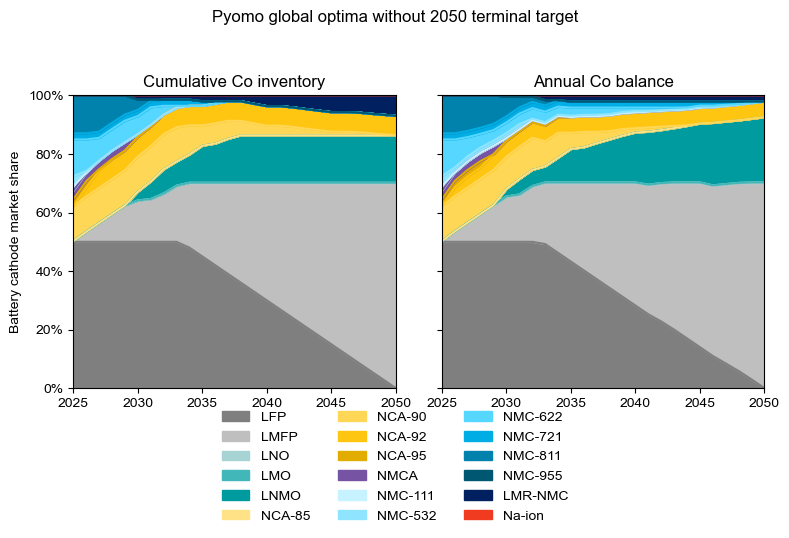

In [51]:
# Final comparison tables and the only visible figure: two market-share panels
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

Cathodes = [
    "LFP", "LMFP", "LNO", "LMO", "LNMO",
    "NCA-85", "NCA-90", "NCA-92", "NCA-95", "NMCA",
    "NMC-111", "NMC-532", "NMC-622", "NMC-721",
    "NMC-811", "NMC-955", "LMR-NMC", "Na-ion",
]
cathode_color_dict = {
    "LFP": "#7F7F7F", "LMFP": "#BFBFBF", "LNO": "#A7D3D4",
    "LMO": "#42B7B9", "LNMO": "#009B9E", "NCA-85": "#FFE285",
    "NCA-90": "#FFD757", "NCA-92": "#FFC611", "NCA-95": "#E2AC00",
    "NMCA": "#7654A3", "NMC-111": "#C7F2FF", "NMC-532": "#8FE4FF",
    "NMC-622": "#56D7FF", "NMC-721": "#00AEE5", "NMC-811": "#0082AC",
    "NMC-955": "#005772", "LMR-NMC": "#002060", "Na-ion": "#F03B20",
}
Cathode_Colors = [cathode_color_dict[c] for c in Cathodes]

print("Dual-policy optimized market shares at key years (%)")
for policy in CO_POLICIES:
    print(f"\n{policy}")
    display((dual_results[policy]["share"].loc[key_years] * 100.0).round(4))
print("Lexicographic GLPK stages")
display(df_Lexicographic_stages_dual)
print("Key-year resource and market comparison")
display(df_Variant_comparison)

plt.close("all")
plt.rc("font", family="Arial")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 10
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharex=True, sharey=True)
panel_titles = {
    "inventory_bank": "Cumulative Co inventory",
    "annual_balance": "Annual Co balance",
}
for ax, policy in zip(axes, CO_POLICIES):
    dual_results[policy]["share"].loc[opt_years, Cathodes].plot.area(
        ax=ax, y=Cathodes, color=Cathode_Colors, legend=False
    )
    ax.set_title(panel_titles[policy])
    ax.set_xlim(2025, 2050)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(2025, 2051, 5))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlabel("")
axes[0].set_ylabel("Battery cathode market share")
axes[1].set_ylabel("")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.06),
    ncol=3, frameon=False,
)
fig.suptitle("Pyomo global optimization", y=0.99)
fig.tight_layout(rect=[0.0, 0.16, 1.0, 0.95])
plt.show()


In [52]:
end_time = time.time()
execution_time = end_time - start_time
hours = execution_time // 3600 
minutes = (execution_time % 3600) // 60 
seconds = execution_time % 60 

print(f"代码运行时间: {int(hours)}小时 {int(minutes)}分钟 {int(seconds)}秒")

代码运行时间: 0小时 17分钟 17秒
